# Seaborn 

## Why Seaborn?
### - provides a layer of abstraction hence simpler to use
### - better aesthetics
### - more graphs included

## Seaborn Roadmap

### - Types of Functions

### - Figure Level
### - Axis Level    
                           
##### - Main Classification

##### - Relational Plot
##### - Distribution Plot
##### - Categorical Plot
##### - Regression Plot
##### - Matrix Plot
##### - Multiplots

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy # for clustermap

## 1. Relational Plot
### - to see the statistical relation between 2 or more variables.
### - Bivariate Analysis
### - Plots under this section

### - scatterplot
### - lineplot

In [2]:
# importing data set

# tips data set
tips = pd.read_csv('data/tips.csv')

# gapminder data set
gap = pd.read_csv('data/gapminder.csv')

# titanic data set
titanic = pd.read_csv('data/titanic.csv')

# iris data set
iris = pd.read_csv('data/iris.csv')

<Axes: xlabel='total_bill', ylabel='tip'>

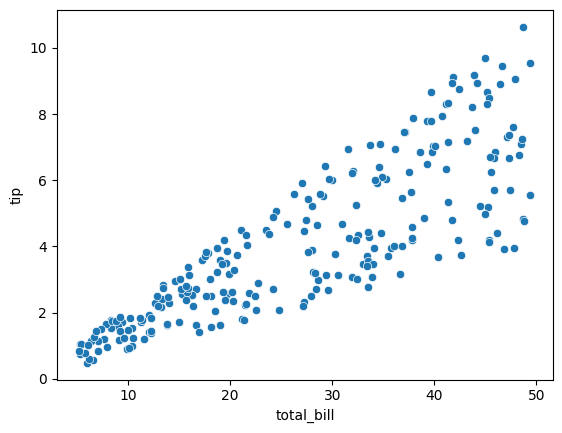

In [3]:
# scatter plot -> axes level function
sns.scatterplot(data=tips,x='total_bill',y='tip')

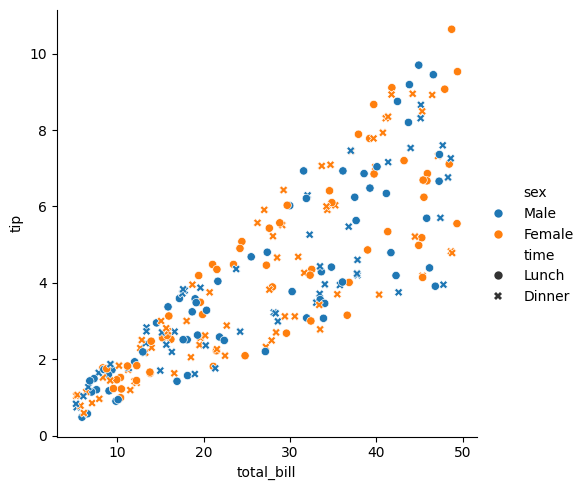

In [4]:
# figure level function

# relplot plot -> fig level function
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',hue='sex',style='time')

<Axes: xlabel='total_bill', ylabel='tip'>

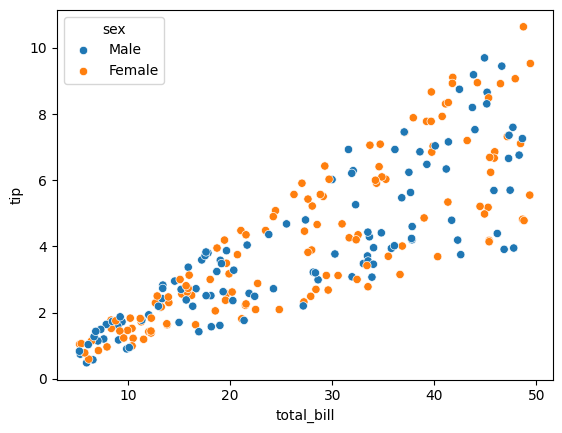

In [5]:
# hue parameter
# scatter plot -> axes level function
sns.scatterplot(data=tips,x='total_bill',y='tip', hue='sex')

<Axes: xlabel='total_bill', ylabel='tip'>

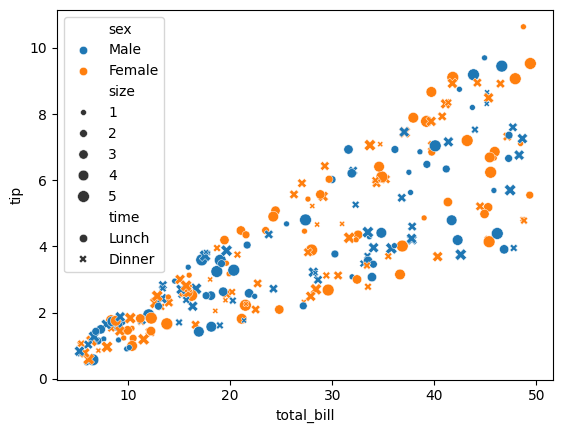

In [6]:
# style parameter
# scatter plot -> axes level function
sns.scatterplot(data=tips,x='total_bill',y='tip', hue='sex',style='time',size='size')

#### Line plot

<Axes: xlabel='year', ylabel='lifeExp'>

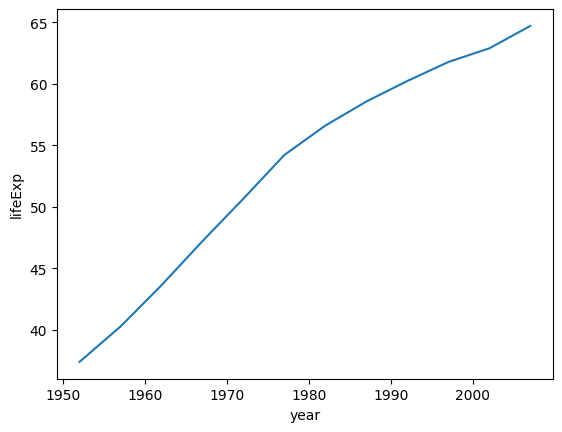

In [7]:
# line plot -> to show continuity


# plot graph of india's lifeExp from from 1952 - 2020


temp_df = gap[gap['country'] == 'India']

# plotting (axes level function)
sns.lineplot(data=temp_df,x='year',y='lifeExp')

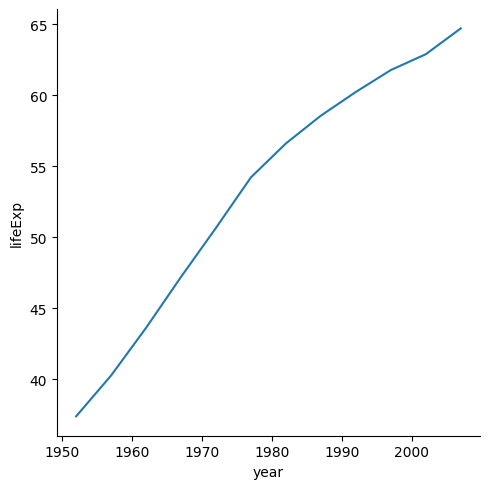

In [8]:
# using relplot
sns.relplot(data=temp_df,x='year',y='lifeExp',kind='line')

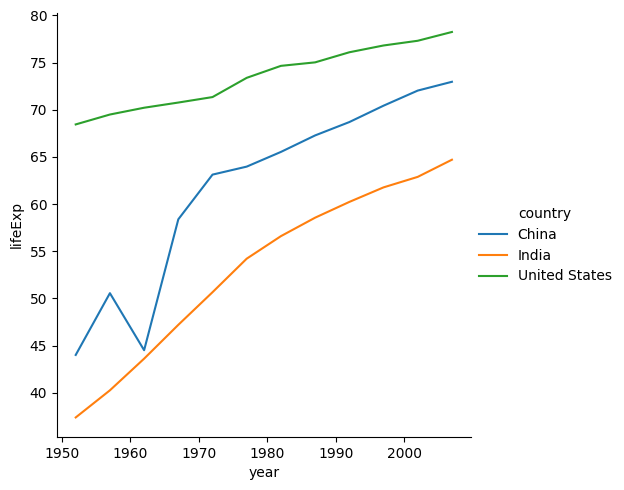

In [9]:
# hue and style parameter 
temp_df = gap[gap['country'].isin(['India','China','United States'])]
sns.relplot(kind='line',data=temp_df,x='year',y='lifeExp',hue='country')

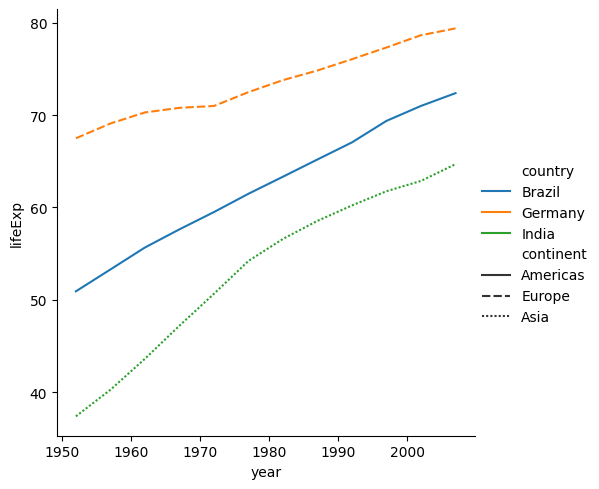

In [10]:
# countries from different continent
temp_df = gap[gap['country'].isin(['India','Brazil','Germany'])]
sns.relplot(kind='line',data=temp_df,x='year',y='lifeExp',hue='country',style='continent')

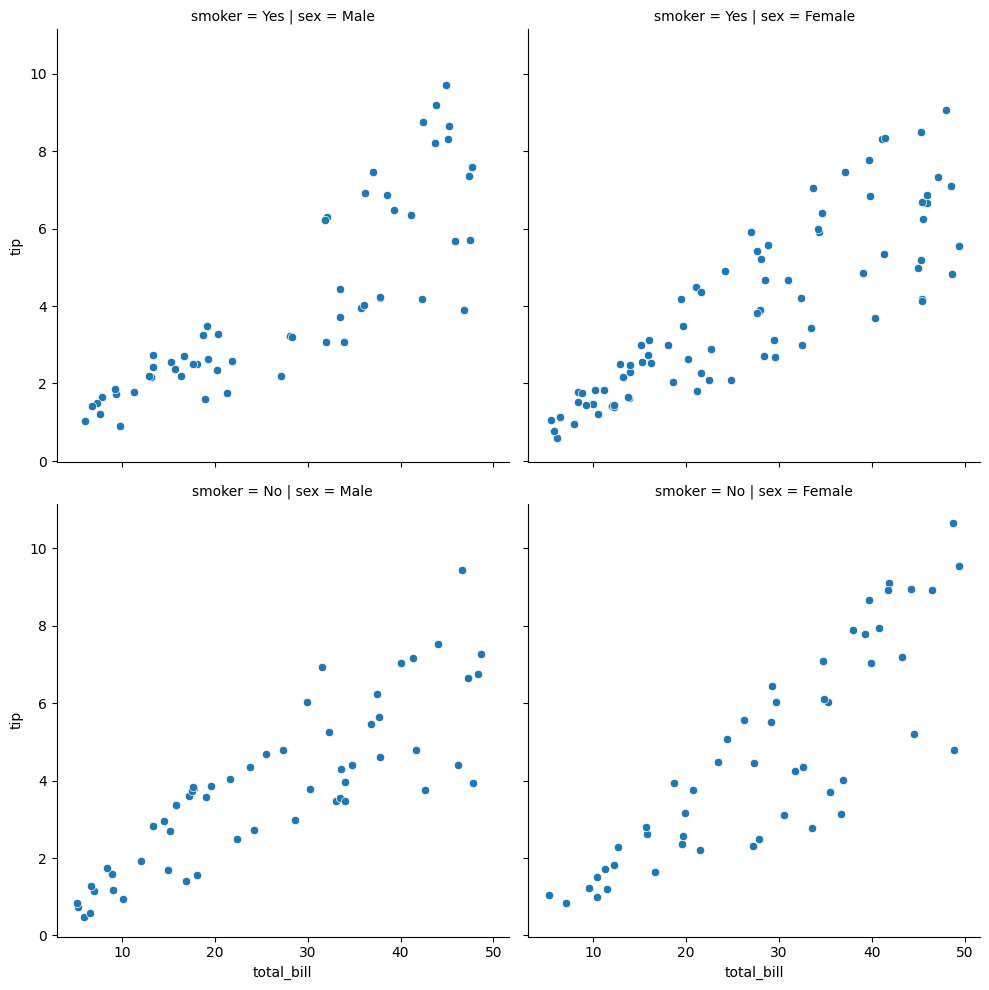

In [11]:
# facet plot -> Facet plots are used to display multiple graphs for different categories of a categorical column
# facet plot -> figure level function -> work with relplot
# it will not work with scatterplot and lineplot
# we'll use col or row parameter
# col for side by side and row for other
sns.relplot(data=tips,x='total_bill',y='tip',row='smoker',col='sex',kind='scatter')

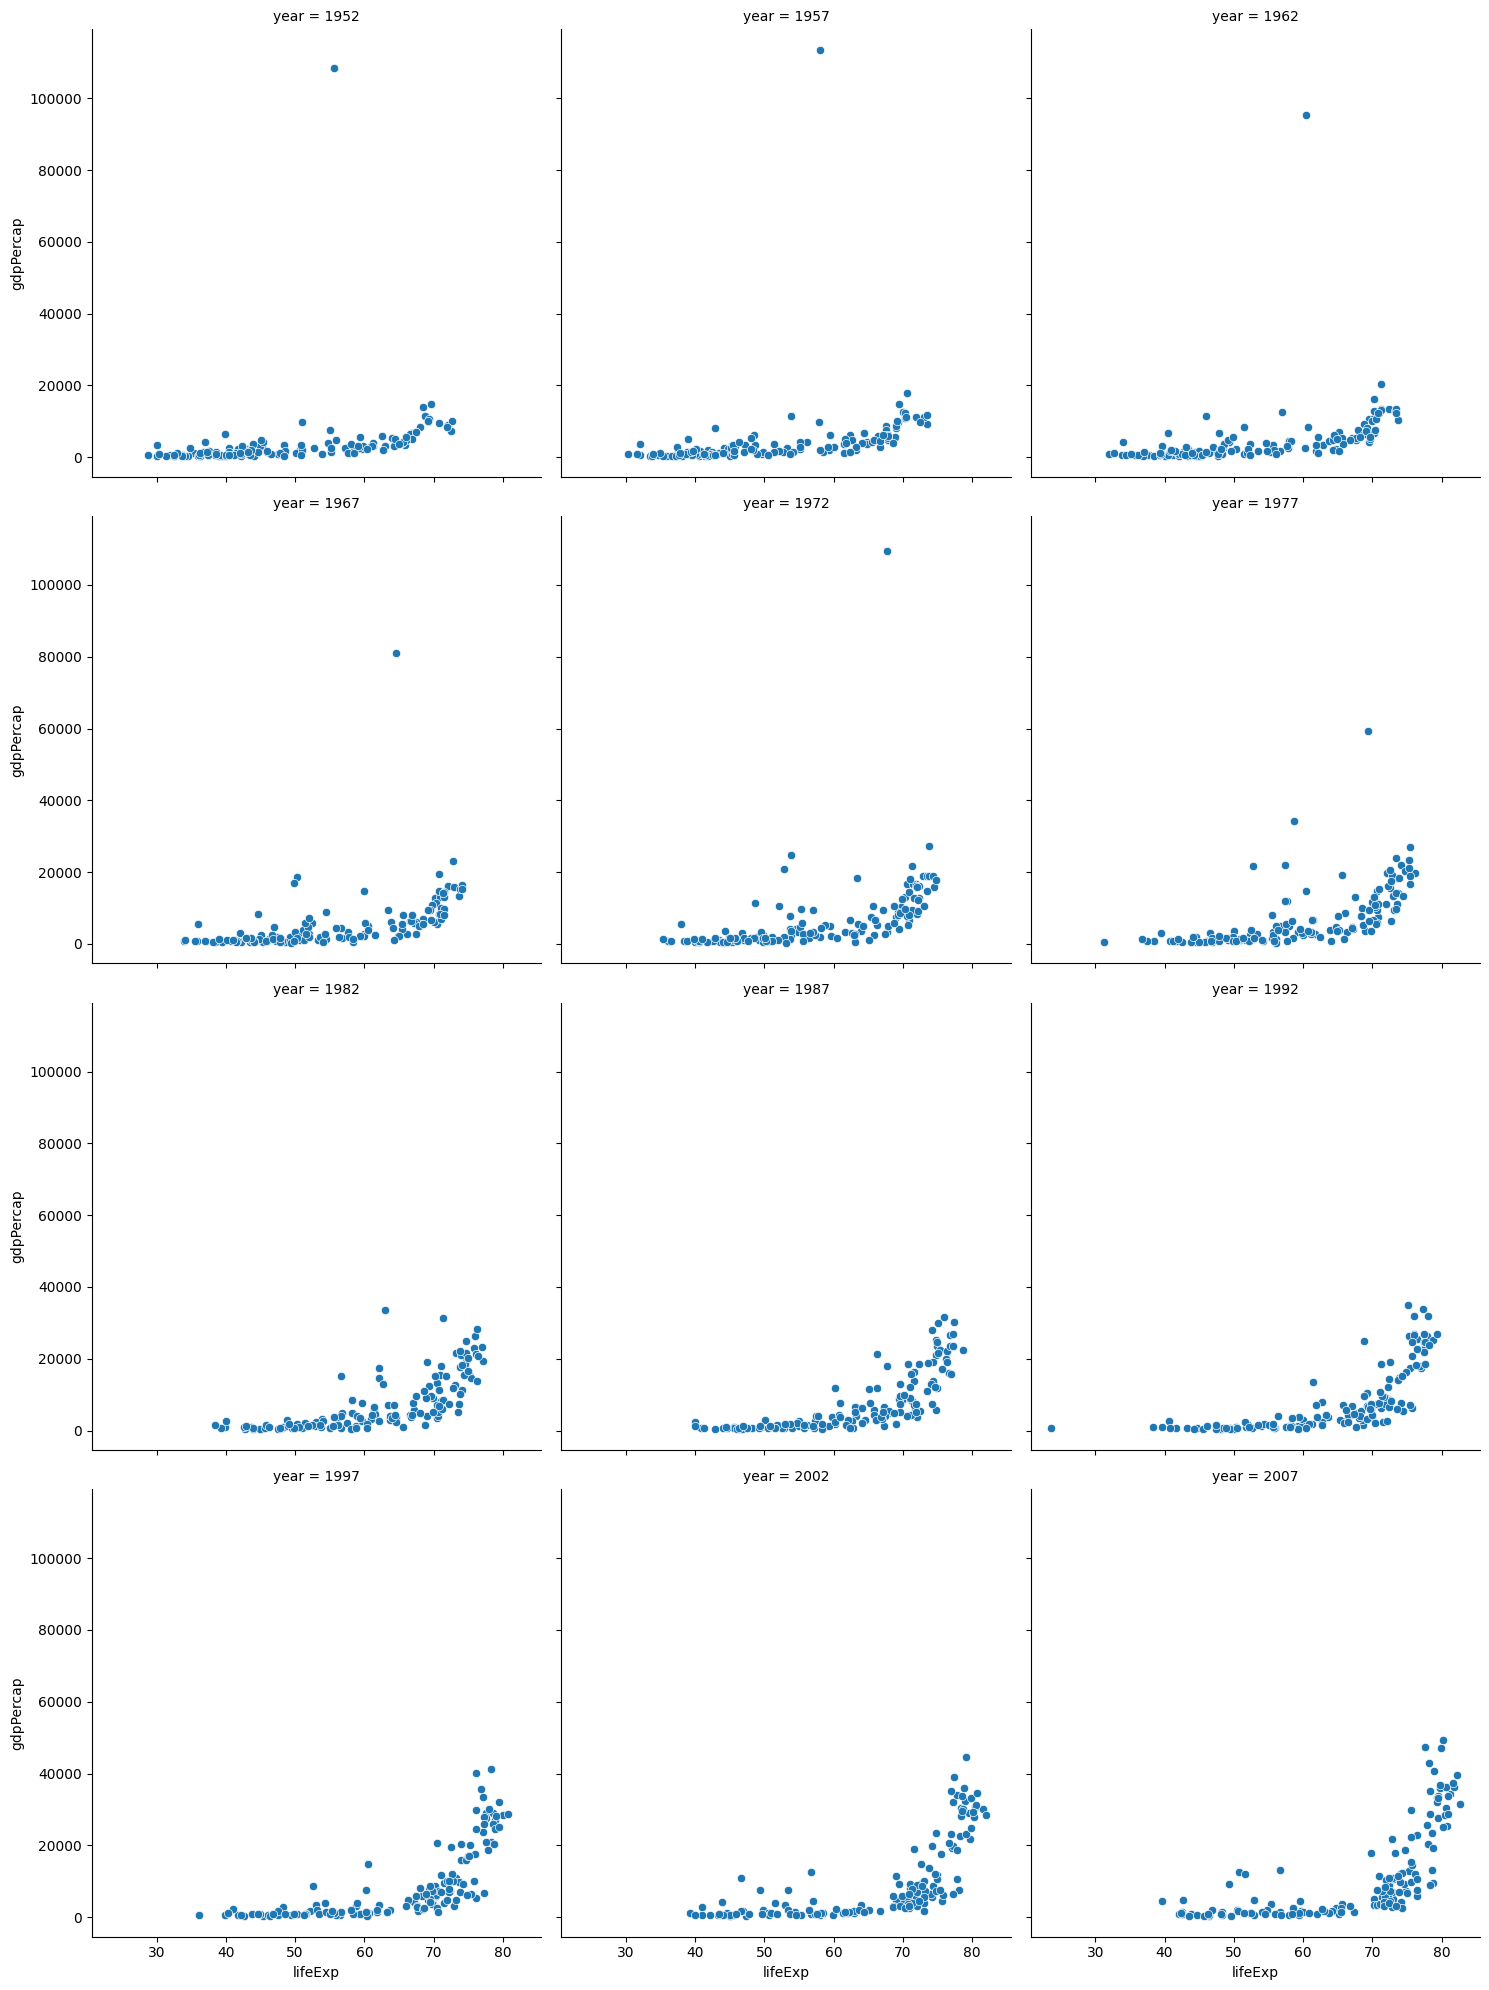

In [12]:
# col wrap
sns.relplot(data=gap, x='lifeExp', y='gdpPercap', kind='scatter', col='year', col_wrap=3)

## 2. Distribution Plots
### - used for univariate analysis
### - used to find out the distribution
### - Range of the observation
### - Central Tendency
### - is the data bimodal?
### - Are there outliers?
### - Plots under distribution plot

#### - histplot
#### - kdeplot
#### - rugplot

In [13]:
# figure level function -> distplot 
# axes level function -> histplot, kdeplot, rugplot

<Axes: xlabel='total_bill', ylabel='Count'>

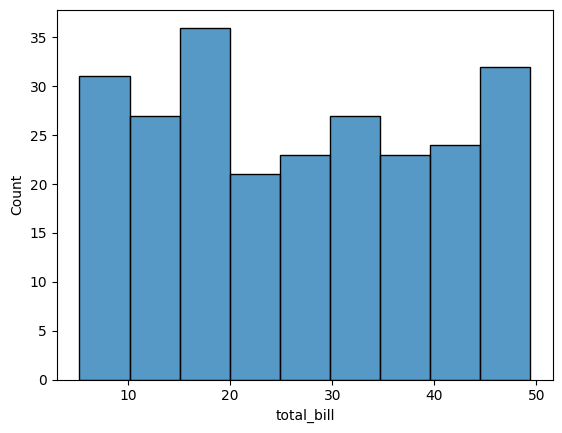

In [14]:
# plotting univariate histogram
sns.histplot(data=tips,x='total_bill')

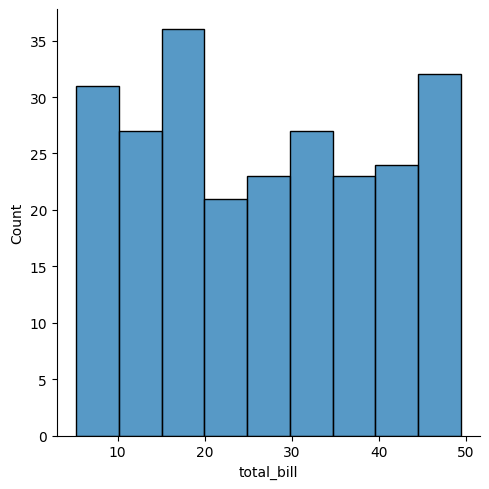

In [15]:
# using distplot
sns.displot(data=tips, x='total_bill',kind='hist')

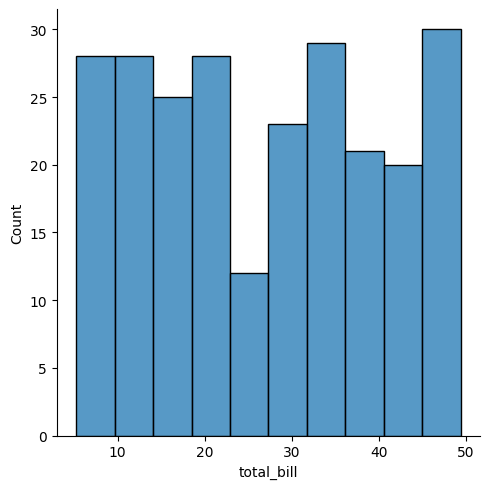

In [16]:
# bins parameter
sns.displot(data=tips, x='total_bill',kind='hist',bins=10)

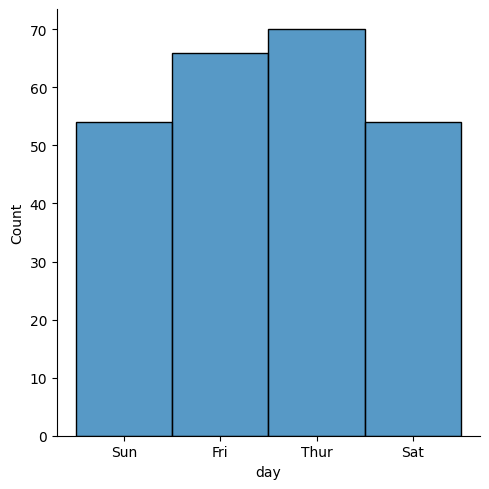

In [17]:
# It’s also possible to visualize the distribution of a categorical variable using the logic of a histogram. 
# Discrete bins are automatically set for categorical variables

# technically as a countplot
sns.displot(data=tips, x='day', kind='hist')

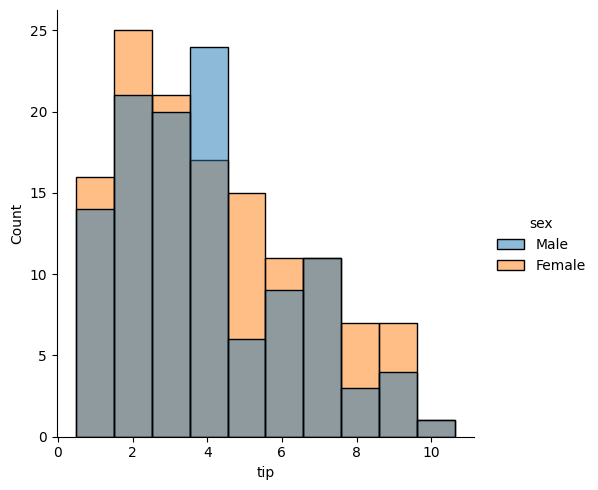

In [18]:
# hue parameter
sns.displot(data=tips, x='tip', kind='hist',hue='sex')

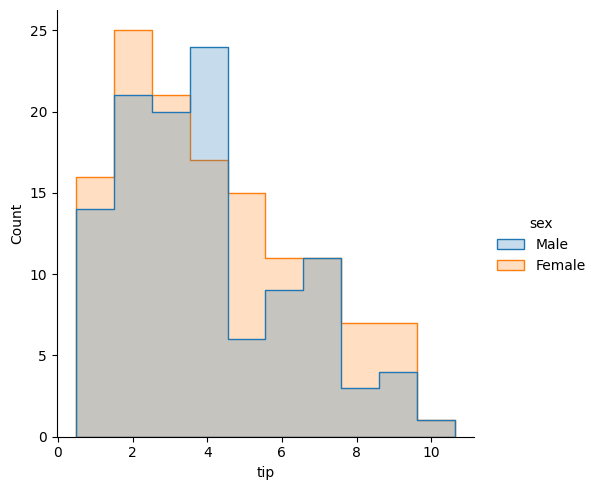

In [19]:
# element=step -> to get a clear picture of the graph
sns.displot(data=tips, x='tip',kind='hist',hue='sex',element='step')

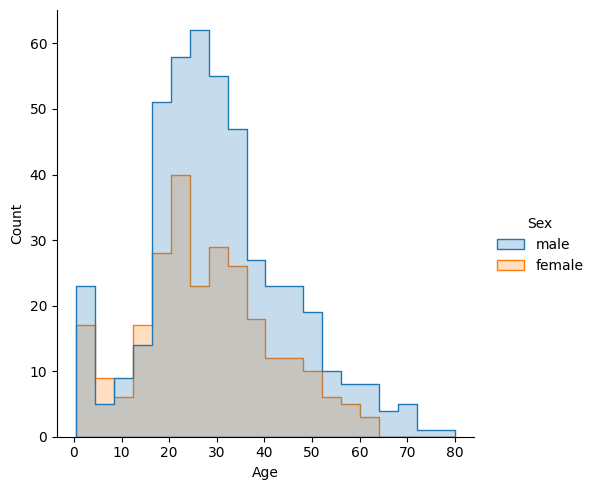

In [20]:
sns.displot(data=titanic, x='Age', kind='hist',element='step',hue='Sex')

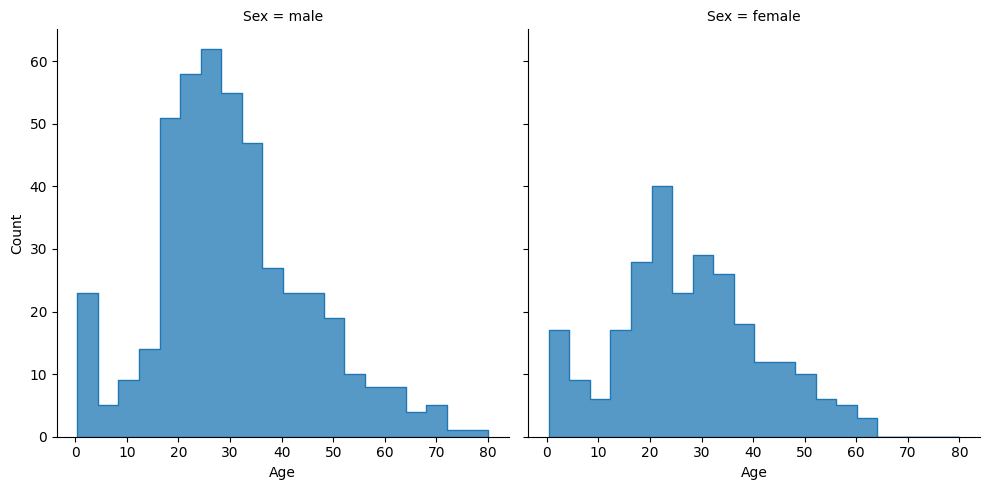

In [21]:
# faceting using col and rows -> this will not work on histplot 
sns.displot(data=titanic, x='Age', kind='hist',element='step',col='Sex')

<Axes: xlabel='total_bill', ylabel='Density'>

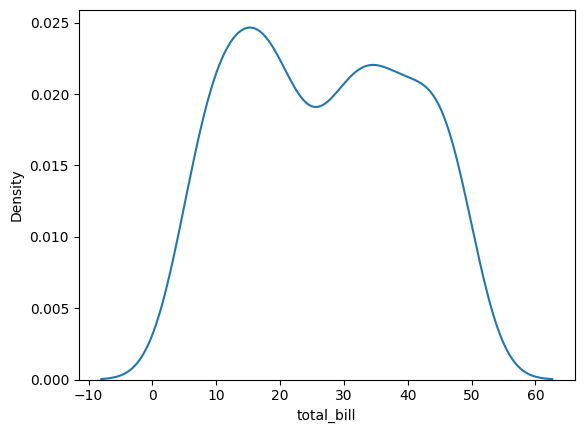

In [22]:
# kdeplot -> Kernel Density Estimation plot
# Rather than using discrete bins, a KDE plot smooths the observations with a Gaussian kernel, producing a continuous density estimate

sns.kdeplot(data=tips,x='total_bill')

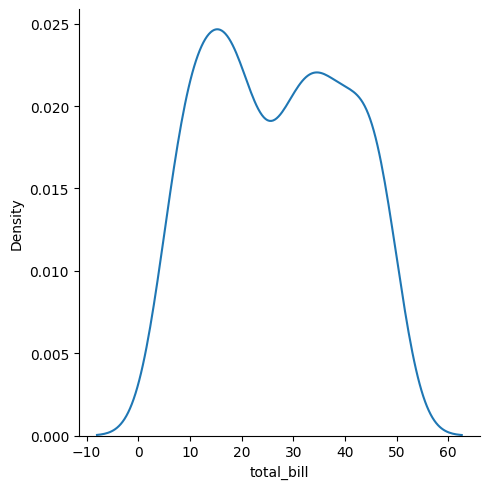

In [23]:
# using displot
sns.displot(data=tips,x='total_bill',kind='kde')


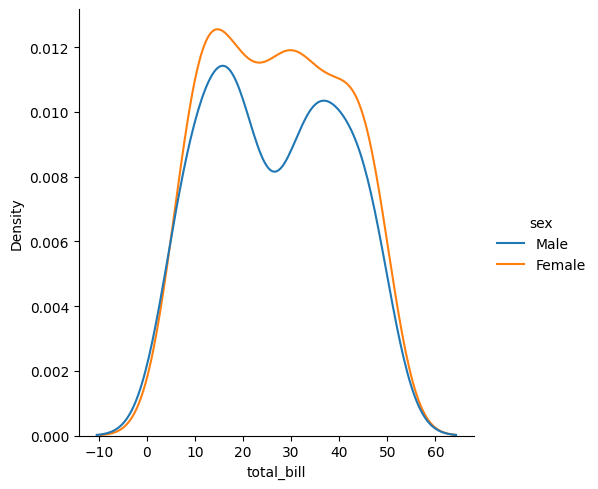

In [24]:
# hue parameter
# we can also use fill = True parameter to fill the graph
sns.displot(data=tips,x='total_bill',kind='kde',hue='sex')

<Axes: xlabel='total_bill', ylabel='Density'>

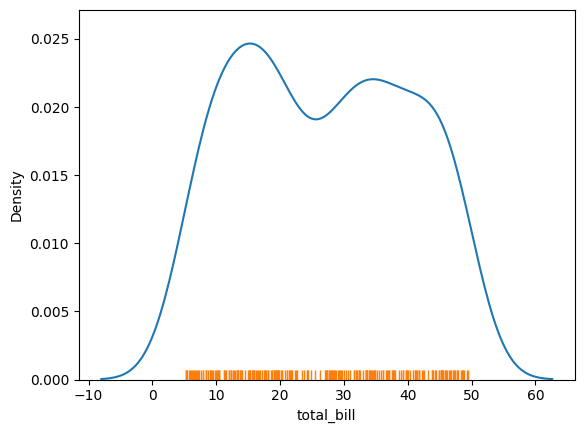

In [25]:
# Rugplot

# Plot marginal distributions by drawing ticks along the x and y axes.

# This function is intended to complement other plots by showing the location of individual observations in an unobtrusive way.

sns.kdeplot(data=tips,x='total_bill')
sns.rugplot(data=tips,x='total_bill')

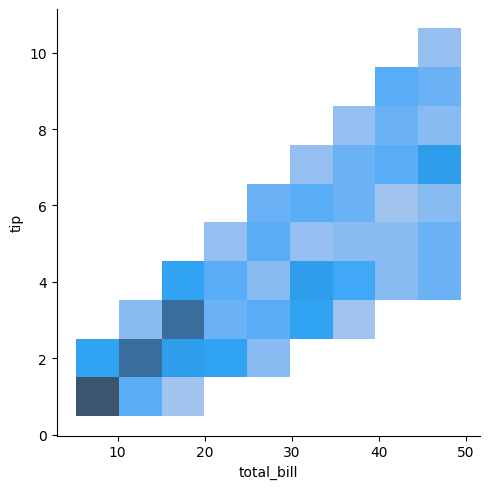

In [26]:
# Bivariate histogram
# A bivariate histogram bins the data within rectangles that tile the plot 
# and then shows the count of observations within each rectangle with the fill color

# sns.histplot(data=tips, x='total_bill', y='tip')
sns.displot(data=tips, x='total_bill', y='tip',kind='hist')

<Axes: xlabel='total_bill', ylabel='tip'>

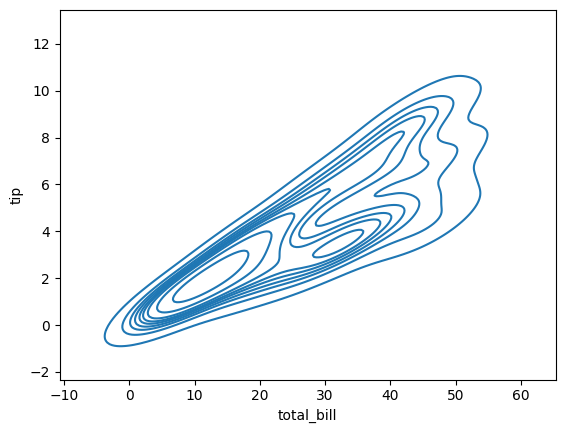

In [27]:
# Bivariate kdeplot
# A Bivariate KDE plot smoothes the x,y observations with 2D Gaussian
sns.kdeplot(data=tips, x='total_bill', y='tip')

## 3. Matrix Plot
### - Heatmap
### - Clustermap

<Axes: xlabel='year', ylabel='country'>

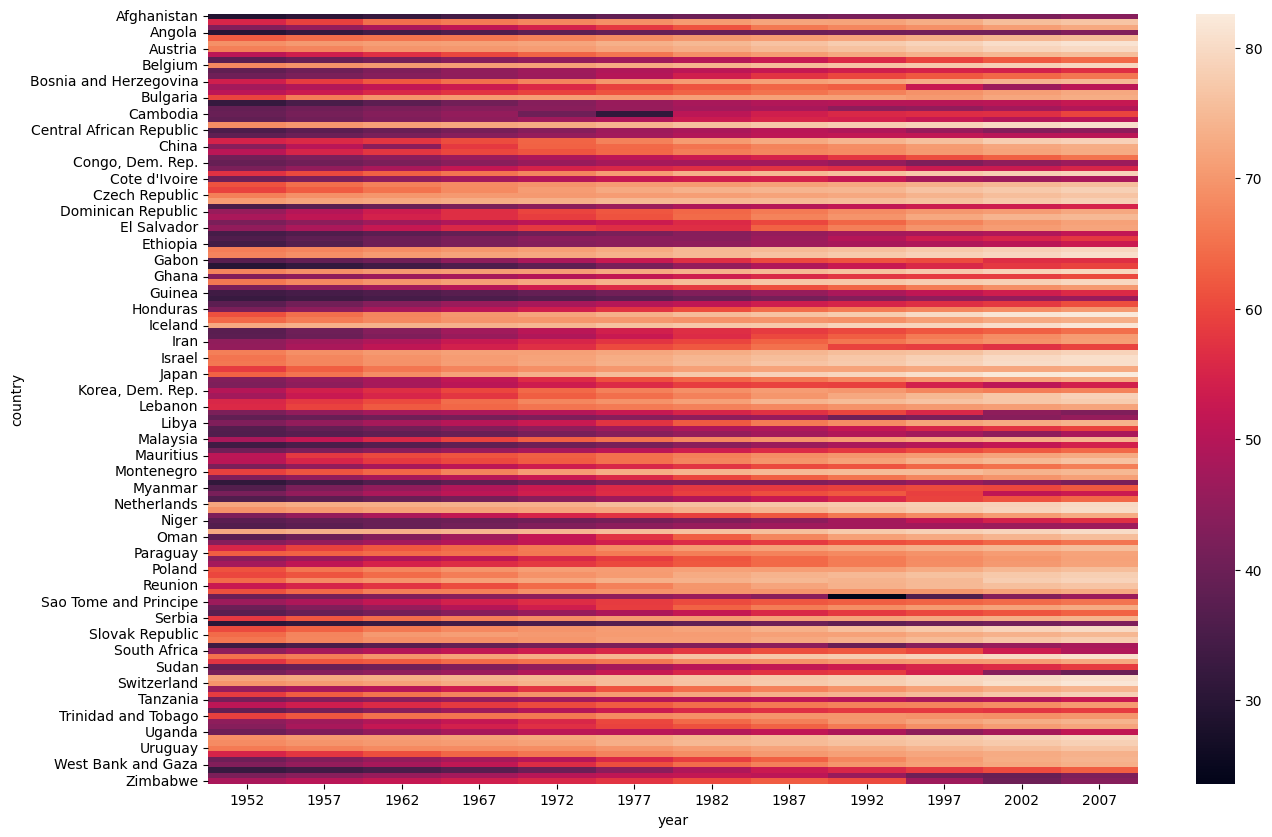

In [28]:
# Heatmap

# Plot rectangular data as a color-encoded matrix
temp_df = gap.pivot(index='country',columns='year',values='lifeExp')

# heatmap -> axes level function (no other way to form heatmap)
plt.figure(figsize=(15,10))
sns.heatmap(temp_df)

<Axes: xlabel='year', ylabel='country'>

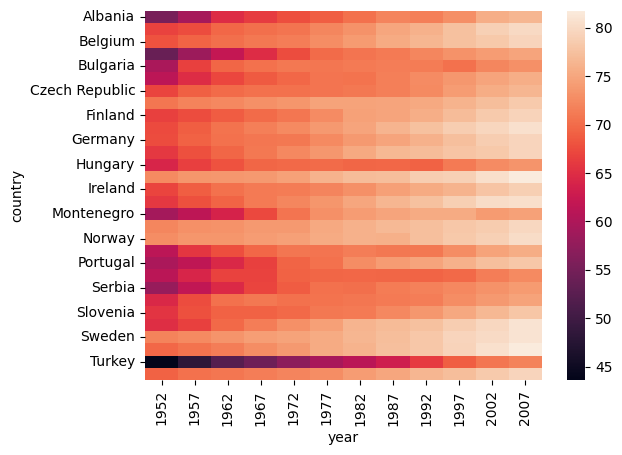

In [29]:
# for europre 
df = gap[gap['continent'] == 'Europe'].pivot(index='country',columns='year',values='lifeExp')
sns.heatmap(df)

<Axes: xlabel='year', ylabel='country'>

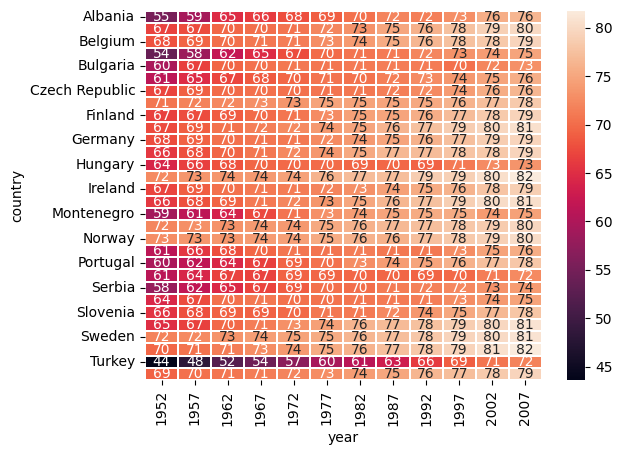

In [30]:
# annotations parameter
sns.heatmap(df,annot=True,linewidths=0.3)

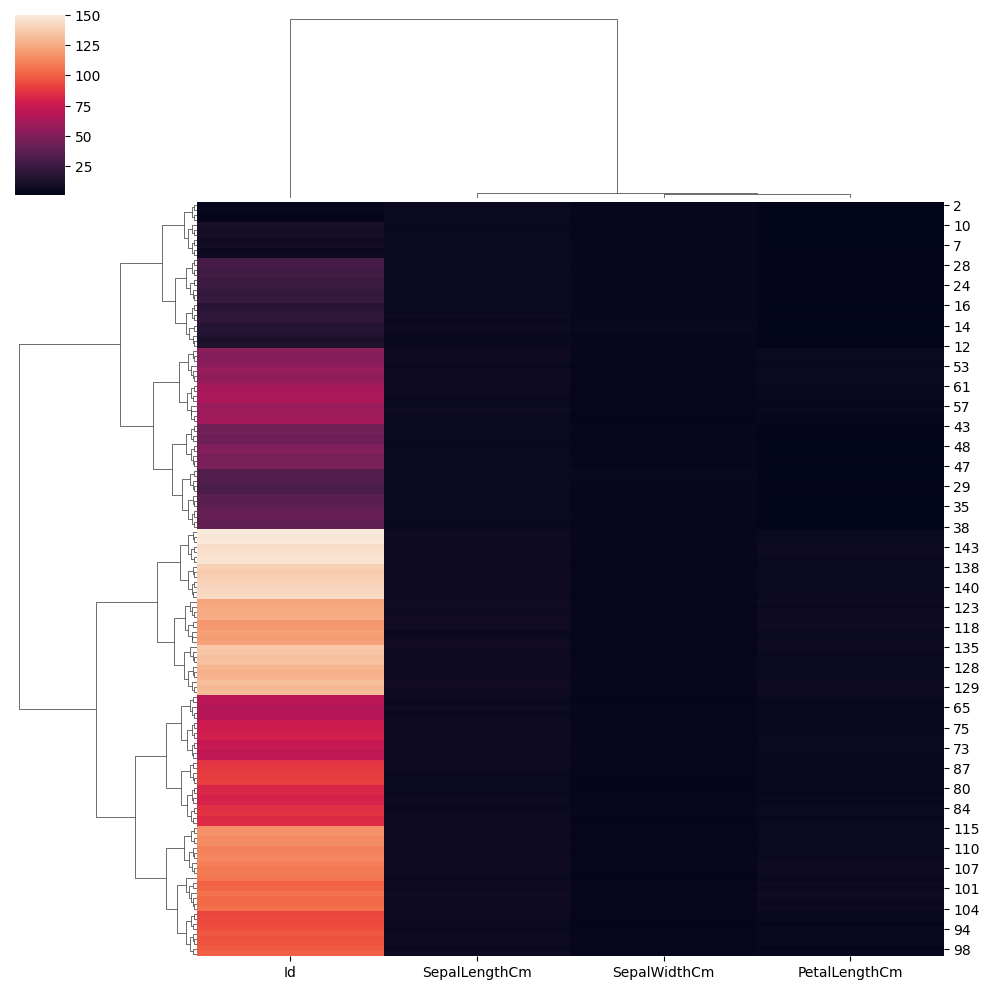

In [31]:
# Clustermap

# Plot a matrix dataset as a hierarchically-clustered heatmap.

# This function requires scipy to be available.
sns.clustermap(iris.iloc[:,[0,1,2,3]])

## Categorical Plots
### - Categorical Scatter Plot
### - Stripplot
### - Swarmplot
### - Categorical Distribution Plots
### - Boxplot
### - Violinplot
## - Categorical Estimate Plot -> for central tendency
### - Barplot
### - Pointplot
### - Countplot
### - Figure level function -> catplot

<Axes: xlabel='day', ylabel='total_bill'>

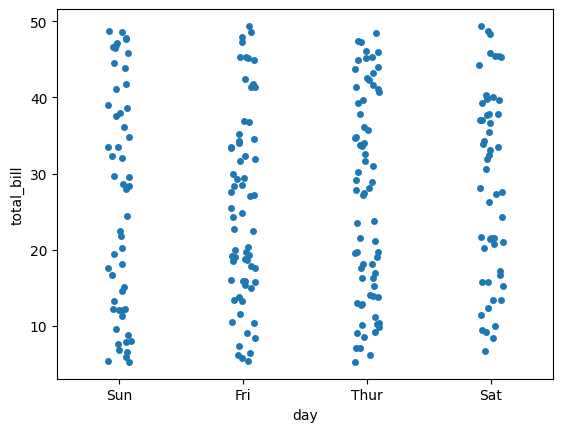

In [32]:
# strip plot -> plot scatterplot between one numerical and one categorical column 

# axes level function
sns.stripplot(data=tips,x='day',y='total_bill') # use jitter=False to remove noise

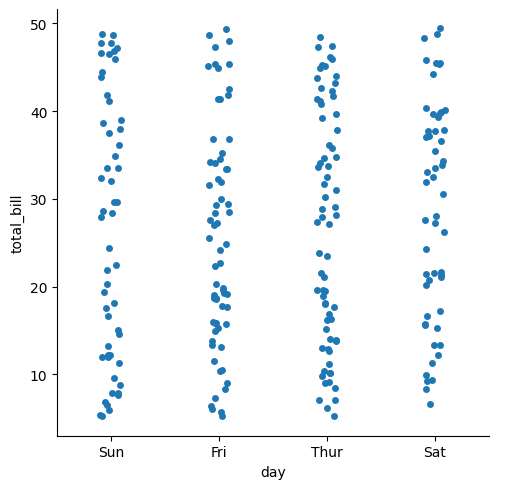

In [33]:
# figure level function
sns.catplot(data=tips,x='day',y='total_bill',kind='strip')

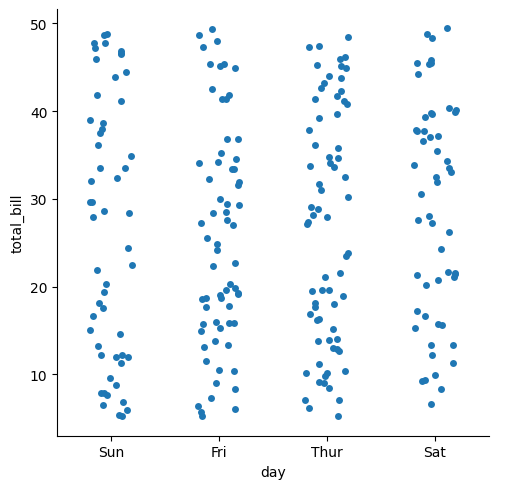

In [34]:
# jitter parameter
sns.catplot(data=tips,x='day',y='total_bill',kind='strip',jitter=0.2)

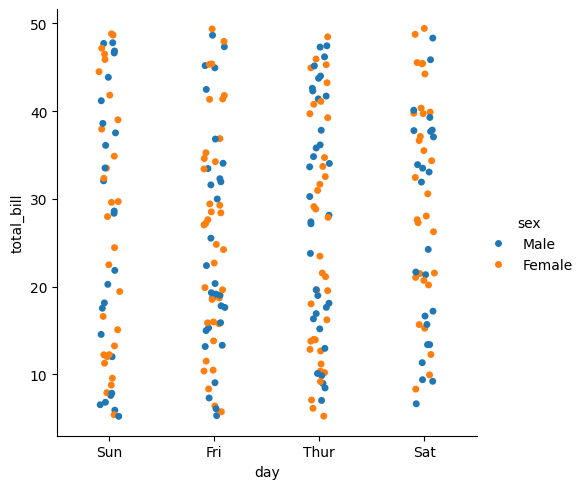

In [35]:
# hue parameter
sns.catplot(data=tips,x='day',y='total_bill',kind='strip',hue='sex')

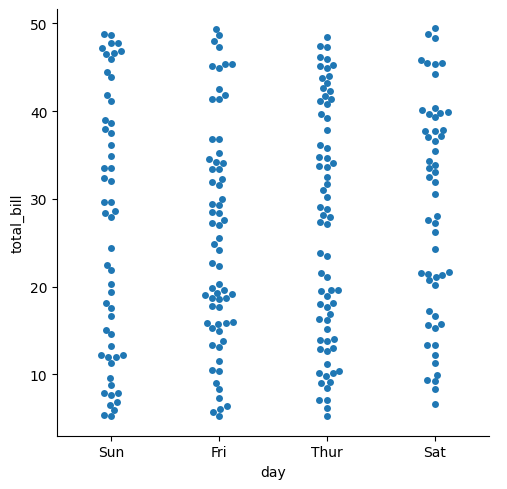

In [36]:
# swarmplot -> using figure level function
sns.catplot(data=tips,x='day',y='total_bill',kind='swarm')

<Axes: xlabel='day', ylabel='total_bill'>

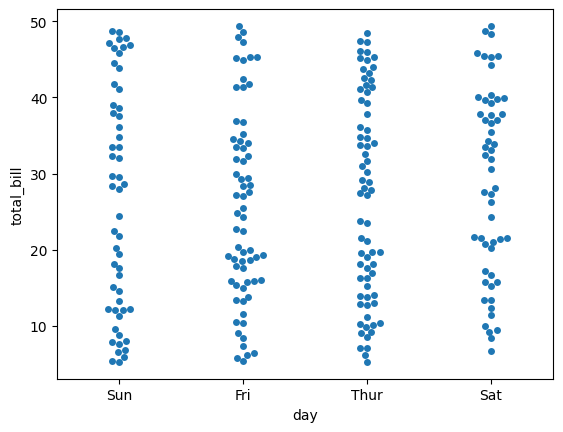

In [37]:
# swarmplot -> using figure axes function
sns.swarmplot(data=tips,x='day',y='total_bill')

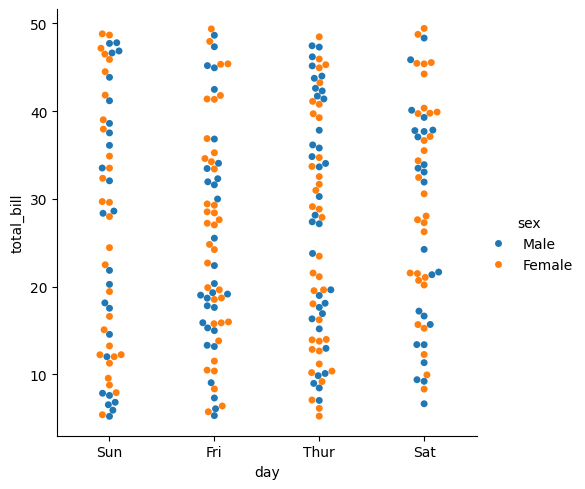

In [38]:
# hue parameter
sns.catplot(data=tips,x='day',y='total_bill',kind='swarm',hue='sex')

## Boxplot

### A boxplot is a standardized way of displaying the distribution of data based on a five number summary (“minimum”, first quartile [Q1], median, third quartile [Q3] and “maximum”). It can tell you about your outliers and what their values are. Boxplots can also tell you if your data is symmetrical, how tightly your data is grouped and if and how your data is skewed.

<Axes: xlabel='sex', ylabel='total_bill'>

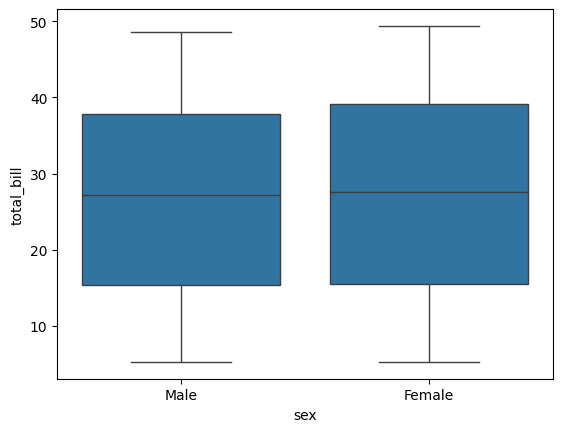

In [39]:
# box plot -> asex level function
sns.boxplot(data=tips,x='sex',y='total_bill')

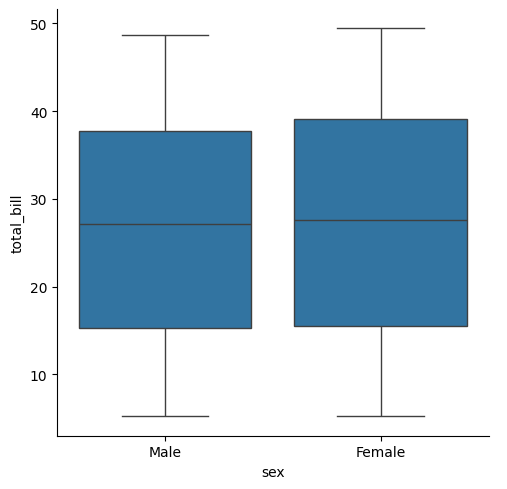

In [40]:
# figure level function
sns.catplot(data=tips,x='sex',y='total_bill',kind='box')

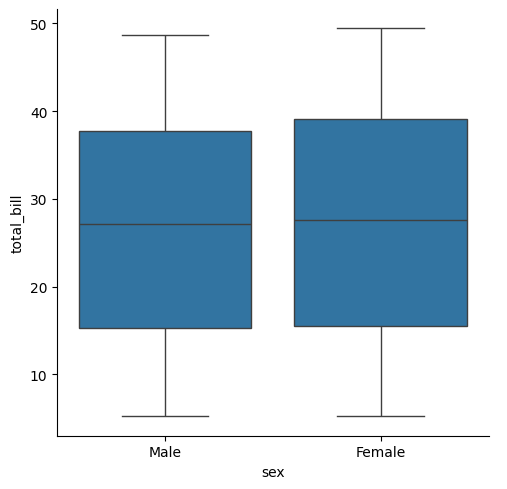

In [41]:
# hue parameter
sns.catplot(data=tips,x='sex',y='total_bill',kind='box')

<Axes: ylabel='total_bill'>

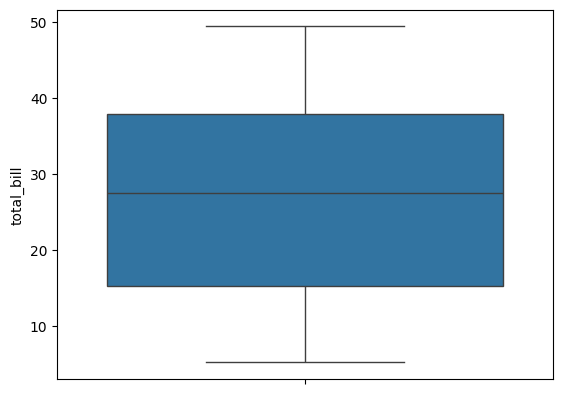

In [42]:
# plot only total bill's box plot
sns.boxplot(data=tips,y='total_bill')

## Violinplot -> Boxplot + kdeplot

<Axes: xlabel='day', ylabel='total_bill'>

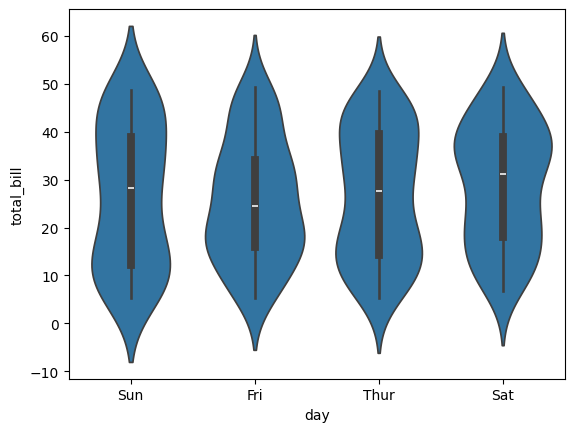

In [43]:
# violin plot -> axes level function
sns.violinplot(data=tips,x='day',y='total_bill')

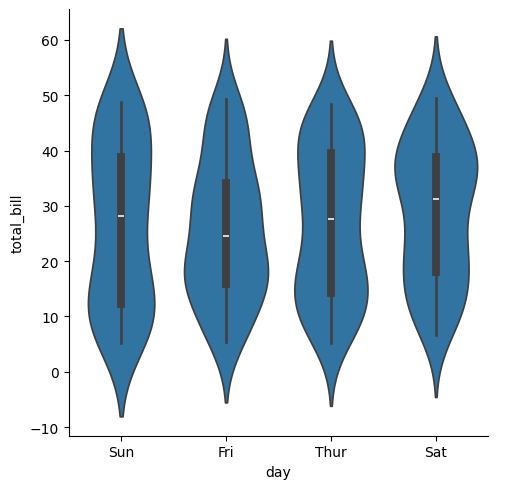

In [44]:
# figure level function
sns.catplot(data=tips,x='day',y='total_bill',kind='violin')

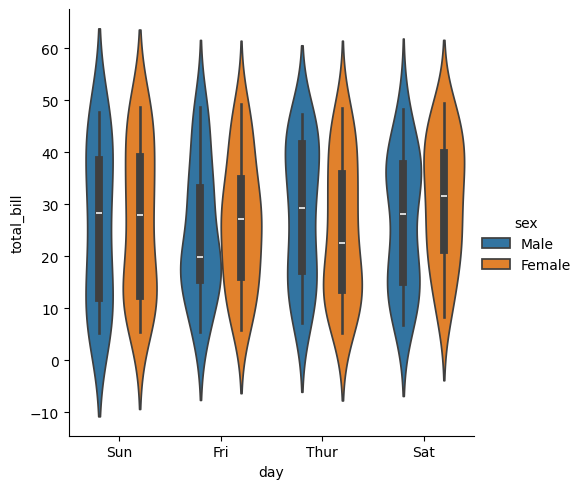

In [45]:
# hue parameter             
sns.catplot(data=tips,x='day',y='total_bill',kind='violin',hue='sex')     

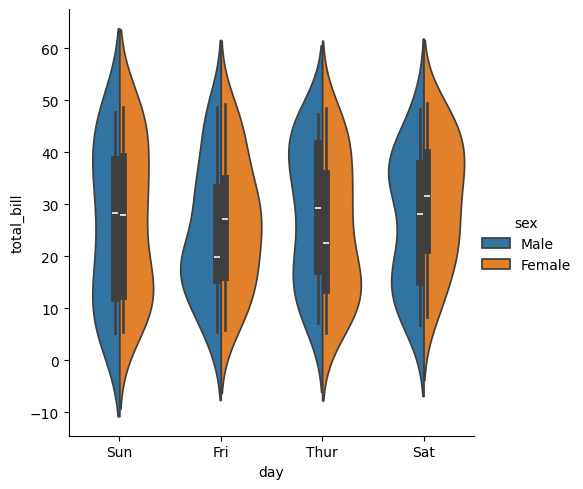

In [46]:
# split parameter
sns.catplot(data=tips,x='day',y='total_bill',kind='violin',hue='sex',split=True)   

<Axes: xlabel='sex', ylabel='total_bill'>

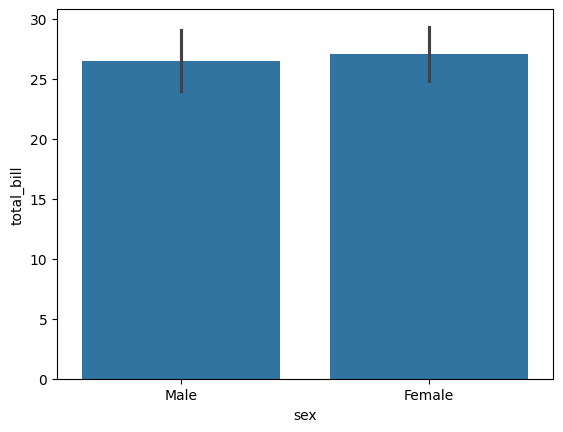

In [47]:
# bar plot
sns.barplot(data=tips,x='sex',y='total_bill') 

### When there are multiple observations in each category, it also uses bootstrapping to compute a confidence interval around the estimate, which is plotted using error bars

<Axes: xlabel='sex', ylabel='total_bill'>

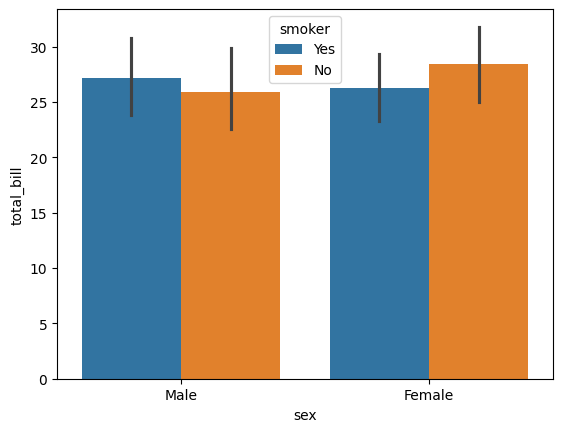

In [48]:
# hue parameter
sns.barplot(data=tips,x='sex',y='total_bill',hue='smoker') 

<Axes: xlabel='sex', ylabel='total_bill'>

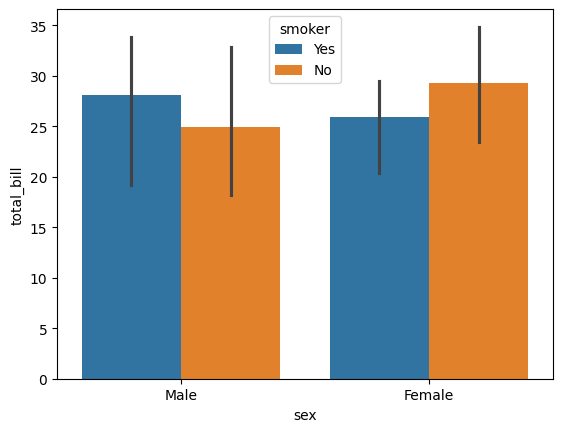

In [49]:
# estimator -> to perform calculations like mean, sd etc
sns.barplot(data=tips,x='sex',y='total_bill',hue='smoker',estimator=np.median) # np.min, np.max etc

<Axes: xlabel='sex', ylabel='total_bill'>

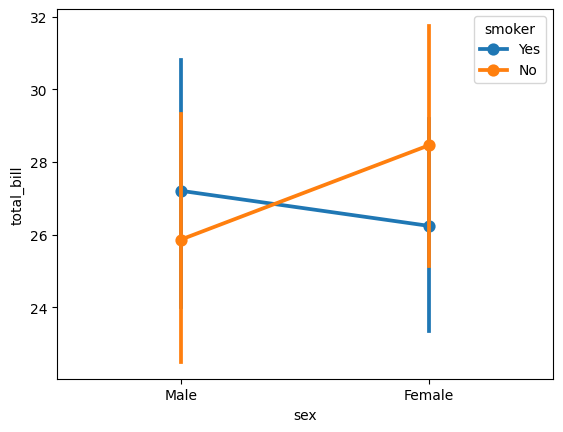

In [50]:
# pointplot (connects the error bars) (give difference b/w two)
sns.pointplot(data=tips,x='sex',y='total_bill',hue='smoker')

<Axes: xlabel='sex', ylabel='count'>

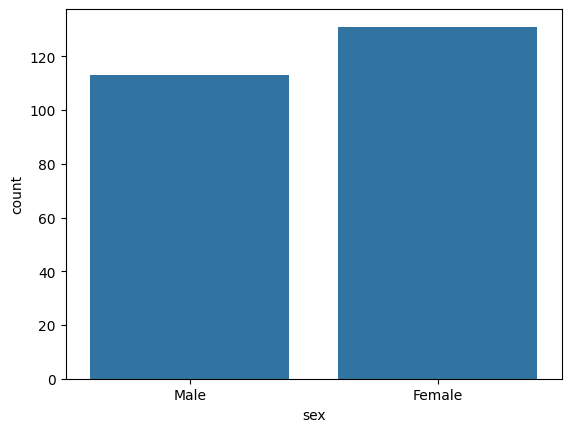

In [51]:
# countplot -> for categorical values
sns.countplot(data=tips,x='sex')

<Axes: xlabel='sex', ylabel='count'>

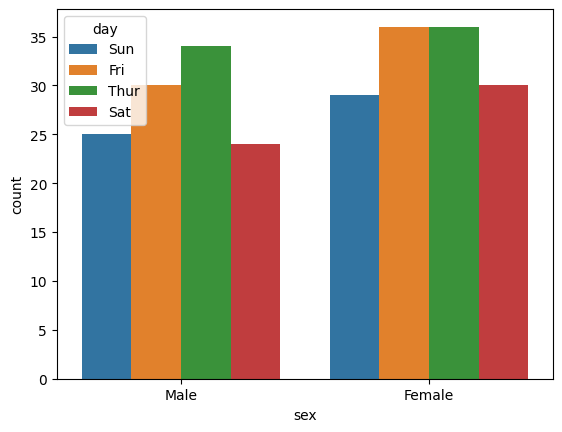

In [52]:
# hue parameter
sns.countplot(data=tips,x='sex',hue='day')

### A special case for the bar plot is when you want to show the number of observations in each category rather than computing a statistic for a second variable. This is similar to a histogram over a categorical, rather than quantitative, variable

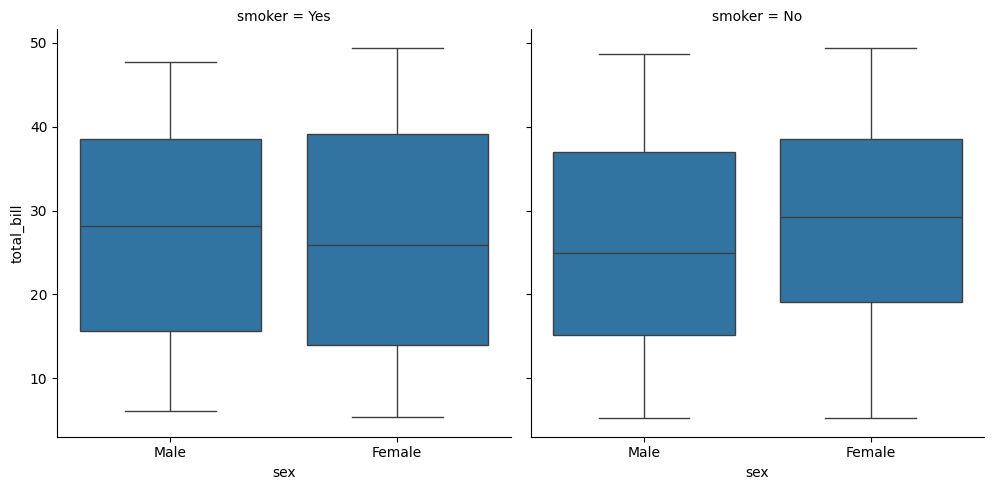

In [53]:
# facet using countplot
sns.catplot(data=tips,x='sex',y='total_bill',col='smoker',kind='box')

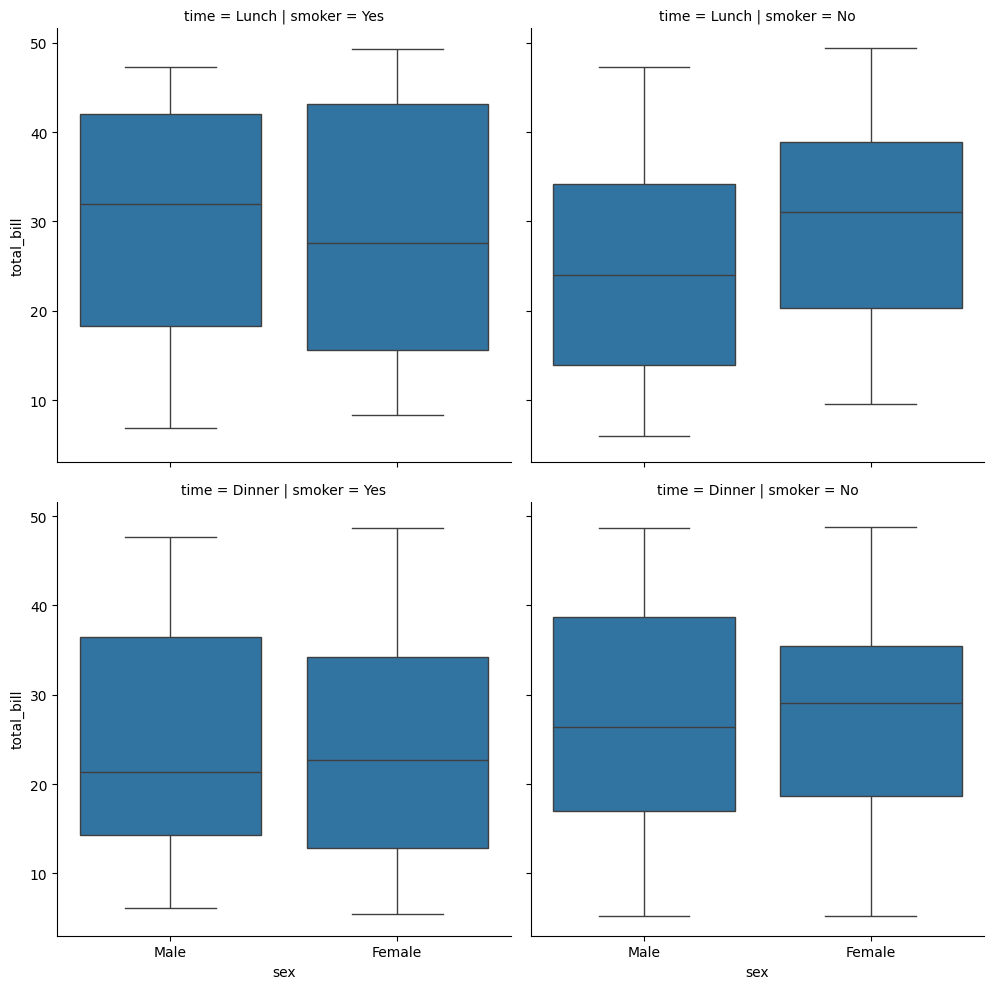

In [54]:
# # facet using countplot (using both col and row)
sns.catplot(data=tips,x='sex',y='total_bill',col='smoker',kind='box',row='time')

## Regression Plots
### - regplot
### - lmplot
### In the simplest invocation, both functions draw a scatterplot of two variables, x and y, and then fit the regression model y ~ x and plot the resulting regression line and a 95% confidence interval for that regression.




<Axes: xlabel='total_bill', ylabel='tip'>

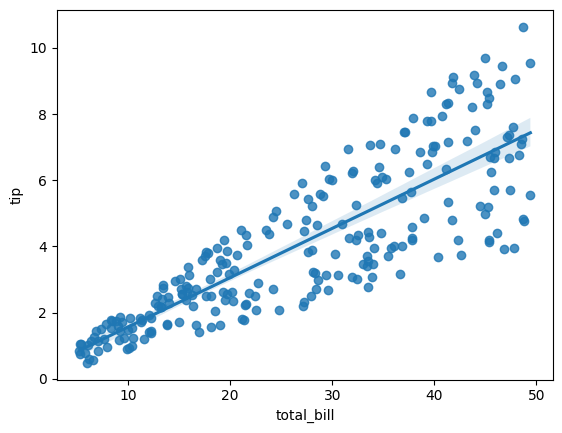

In [55]:
# regplot -> axes level function ( hue parameter is not available)
sns.regplot(data=tips,x='total_bill',y='tip')

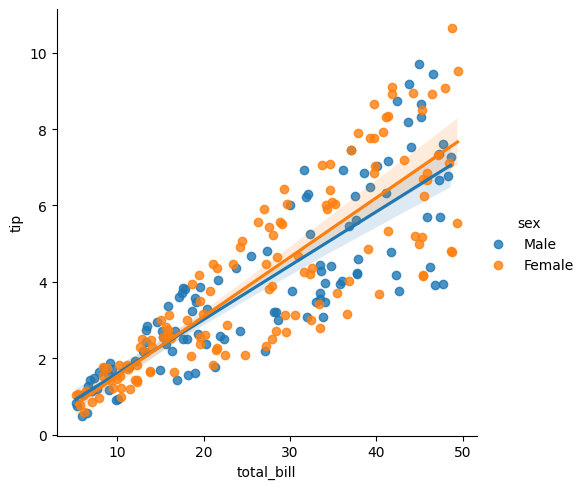

In [56]:
# lmplot -> figure level function (we can add hue parameter)
sns.lmplot(data=tips,x='total_bill',y='tip',hue='sex') 

<Axes: xlabel='total_bill', ylabel='tip'>

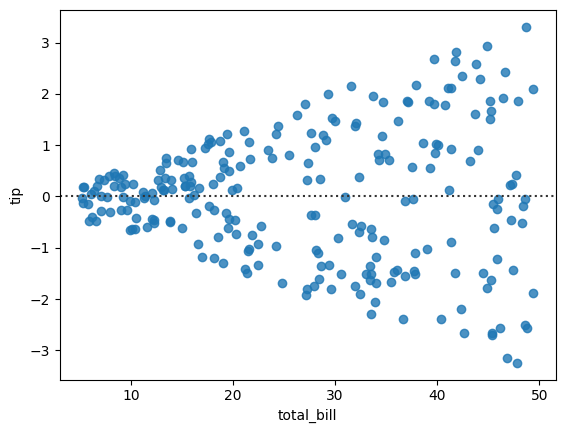

In [57]:
# residplot -> (this is our error while predicting tip)
sns.residplot(data=tips,x='total_bill',y='tip')

## A second way to plot Facet plots -> FacetGrid

/Users/mohit/Documents/seaborn/venv/lib/python3.14/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the violinplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


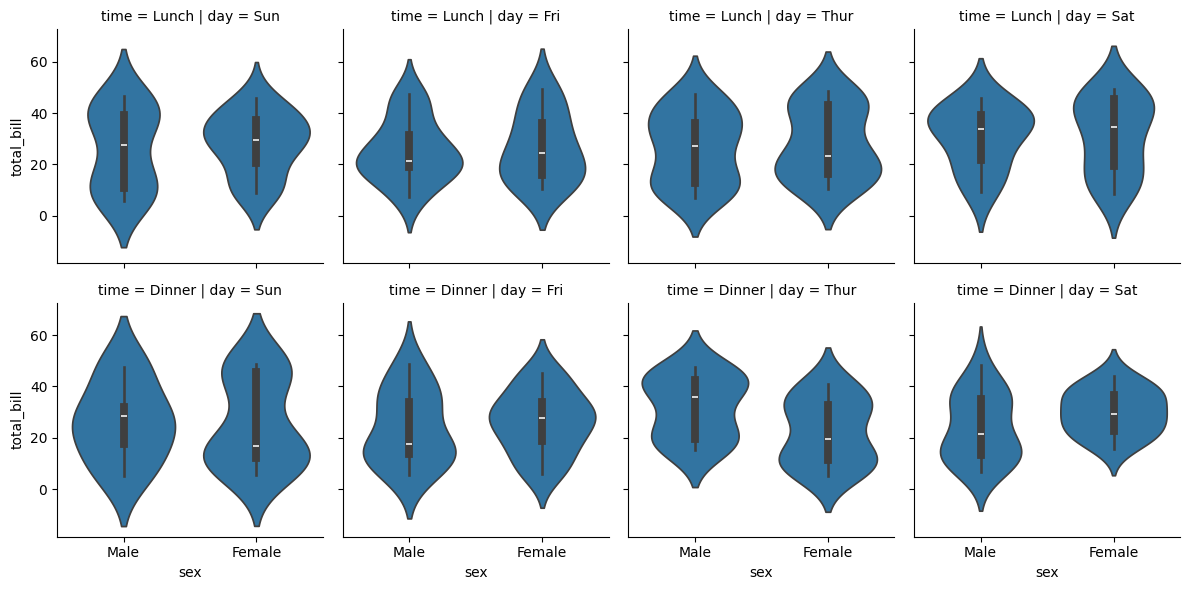

In [67]:
# facetgrid
g = sns.FacetGrid(data=tips, col='day', row='time')
g.map(sns.violinplot,'sex', 'total_bill') # syntax-> which graph,x,y

## Plotting Pairwise Relationship (Pairgrid VS Pairplot)

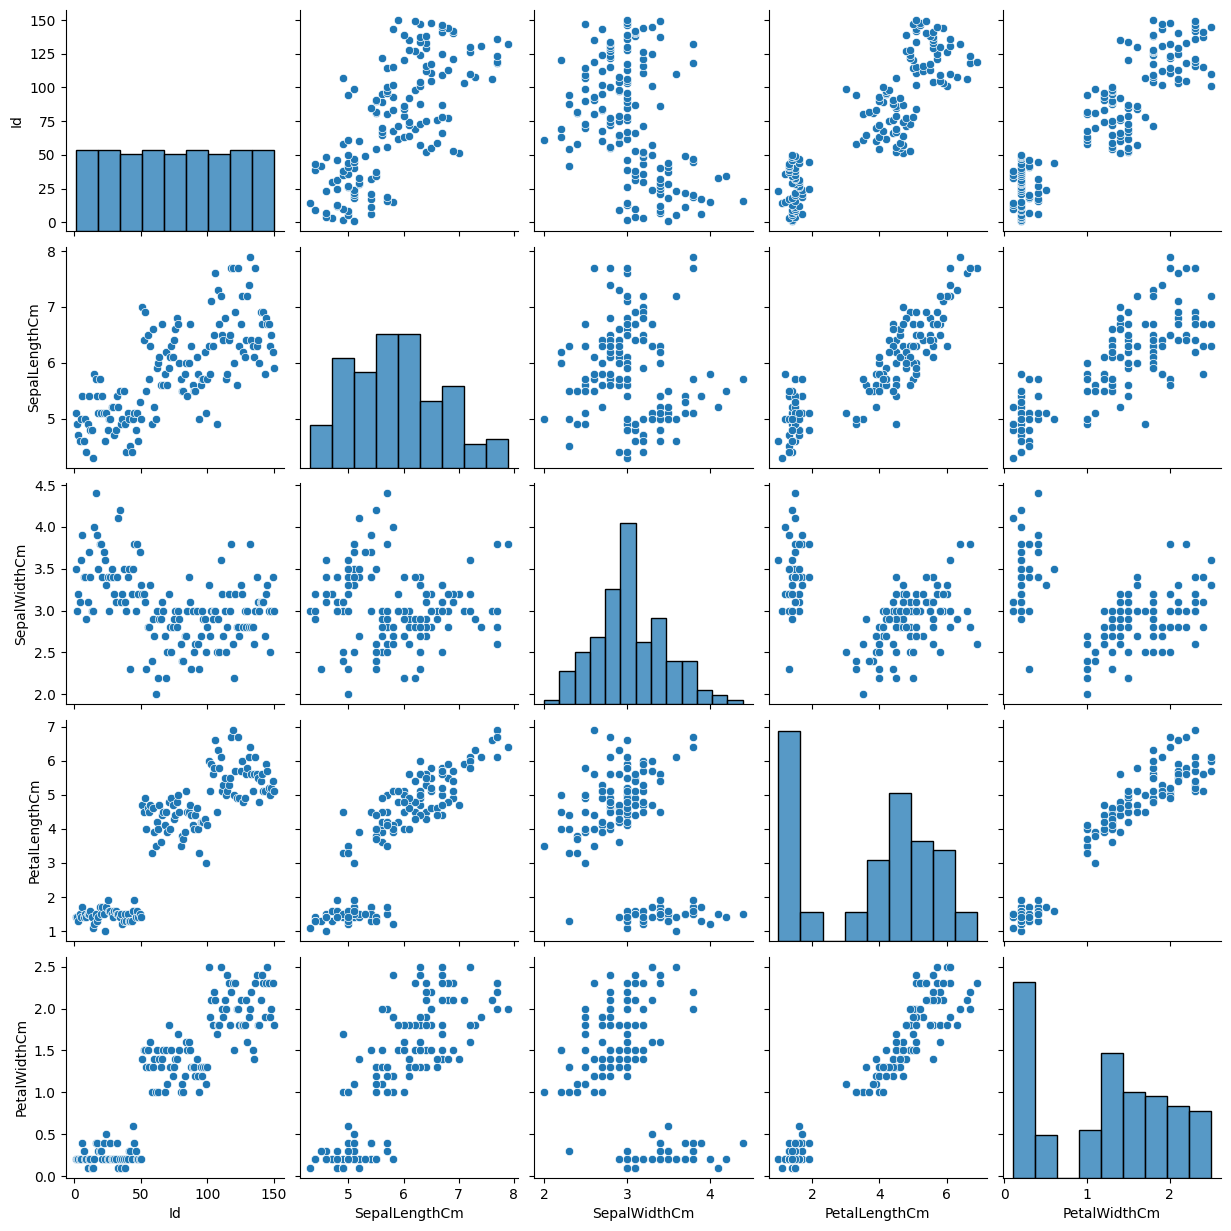

In [70]:
# pairplot -> plot scatterplot between pairs of all the numerical columns in data
# when it will compare two same data -> it will plot  histogram
sns.pairplot(iris)

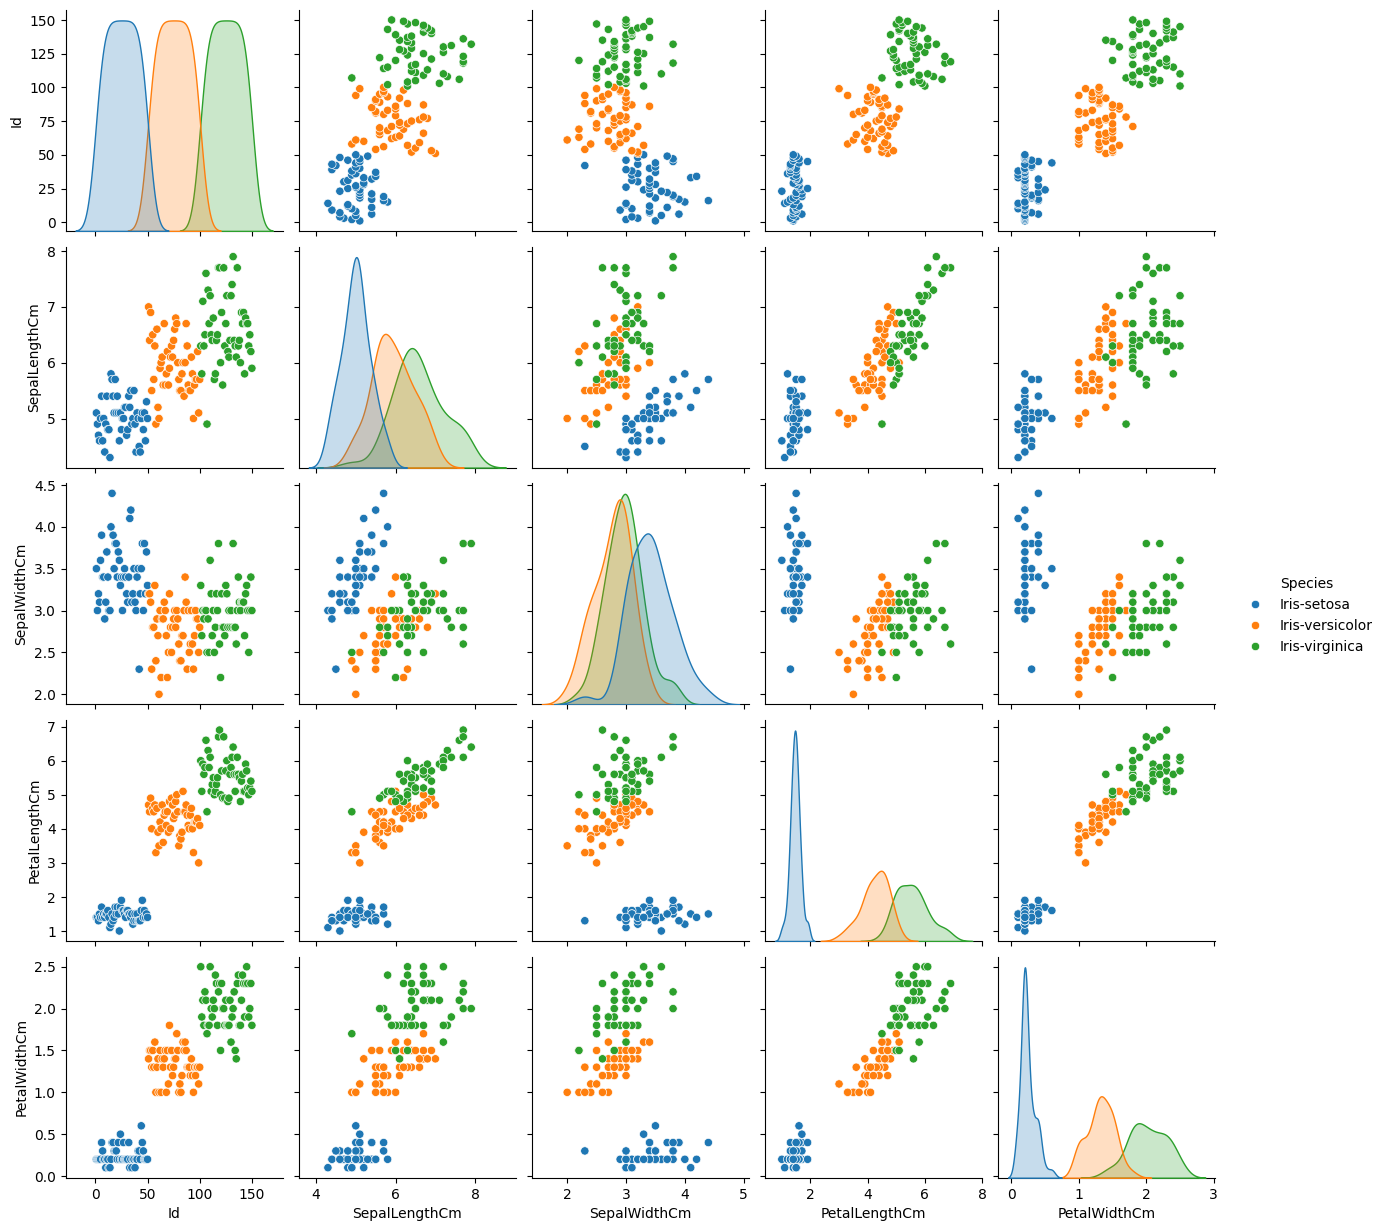

In [77]:
# hue parameter
sns.pairplot(iris,hue='Species') # it will plot kde plot for same data rather than histogram


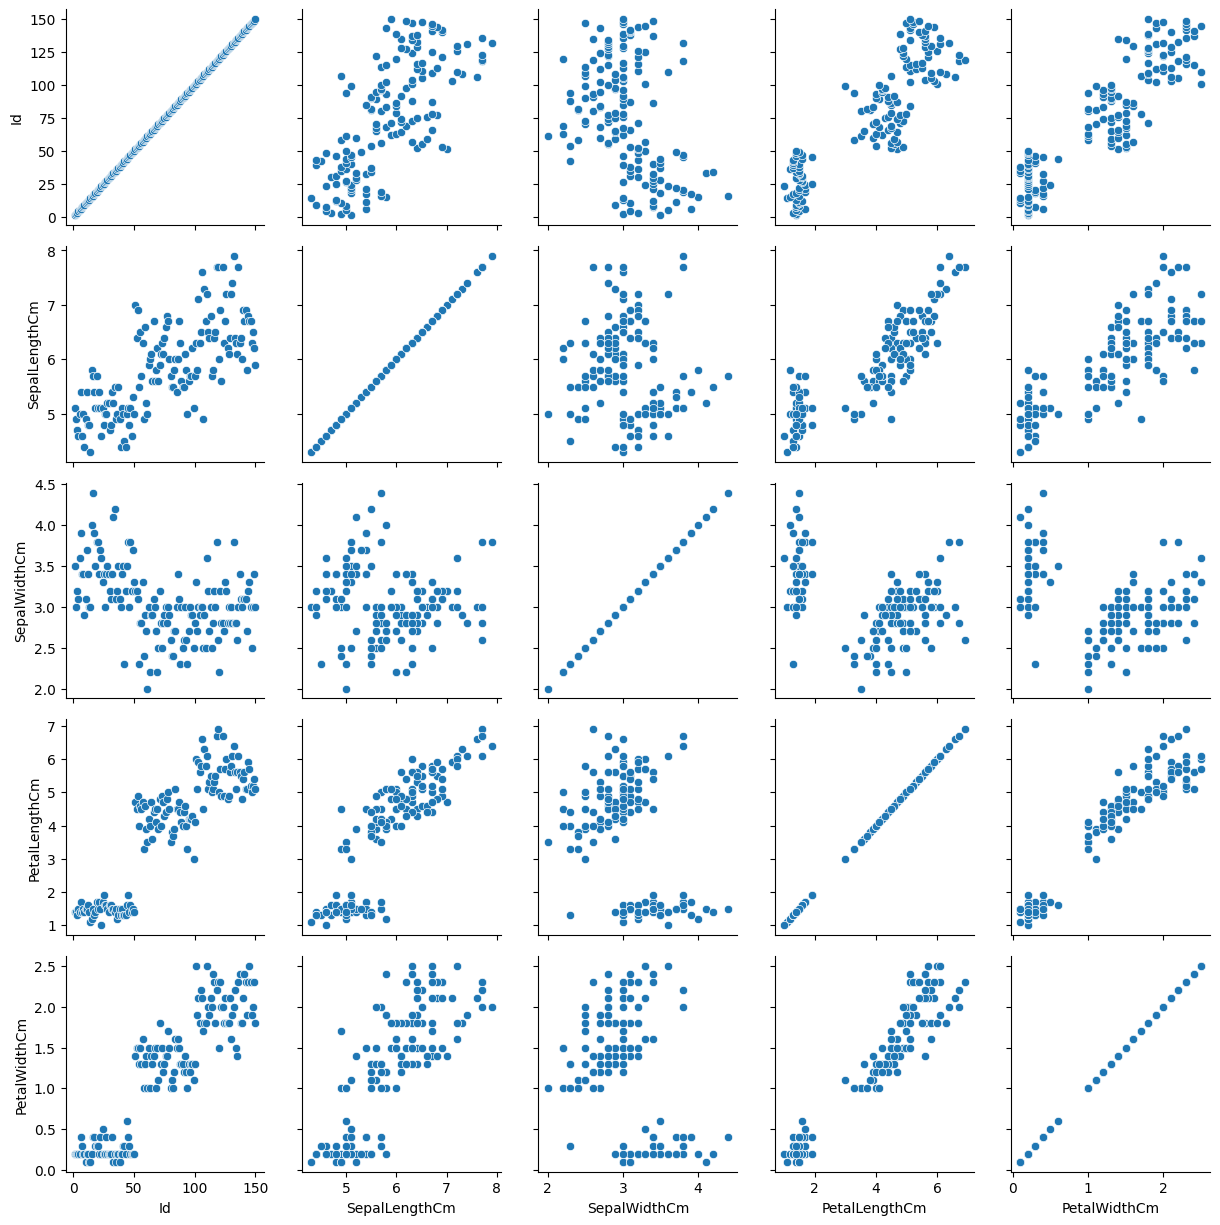

In [82]:
# pairgrid
g = sns.PairGrid(iris)

# g -> grid object
g.map(sns.scatterplot)

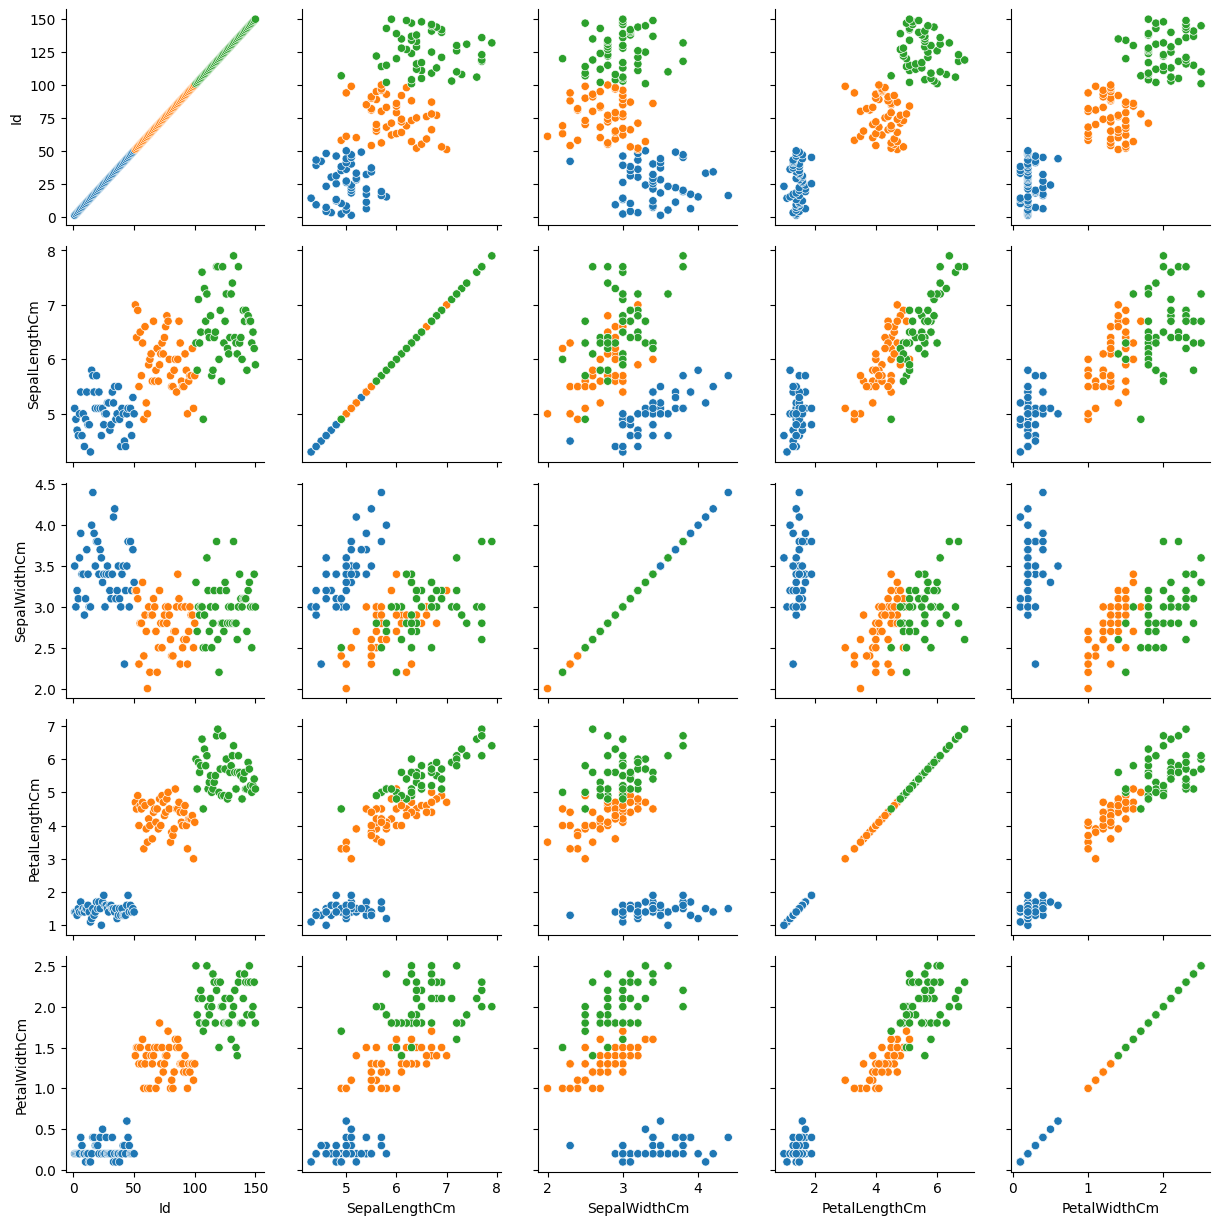

In [83]:
# hue parameter
g = sns.PairGrid(iris,hue='Species')

# g -> grid object
g.map(sns.scatterplot)

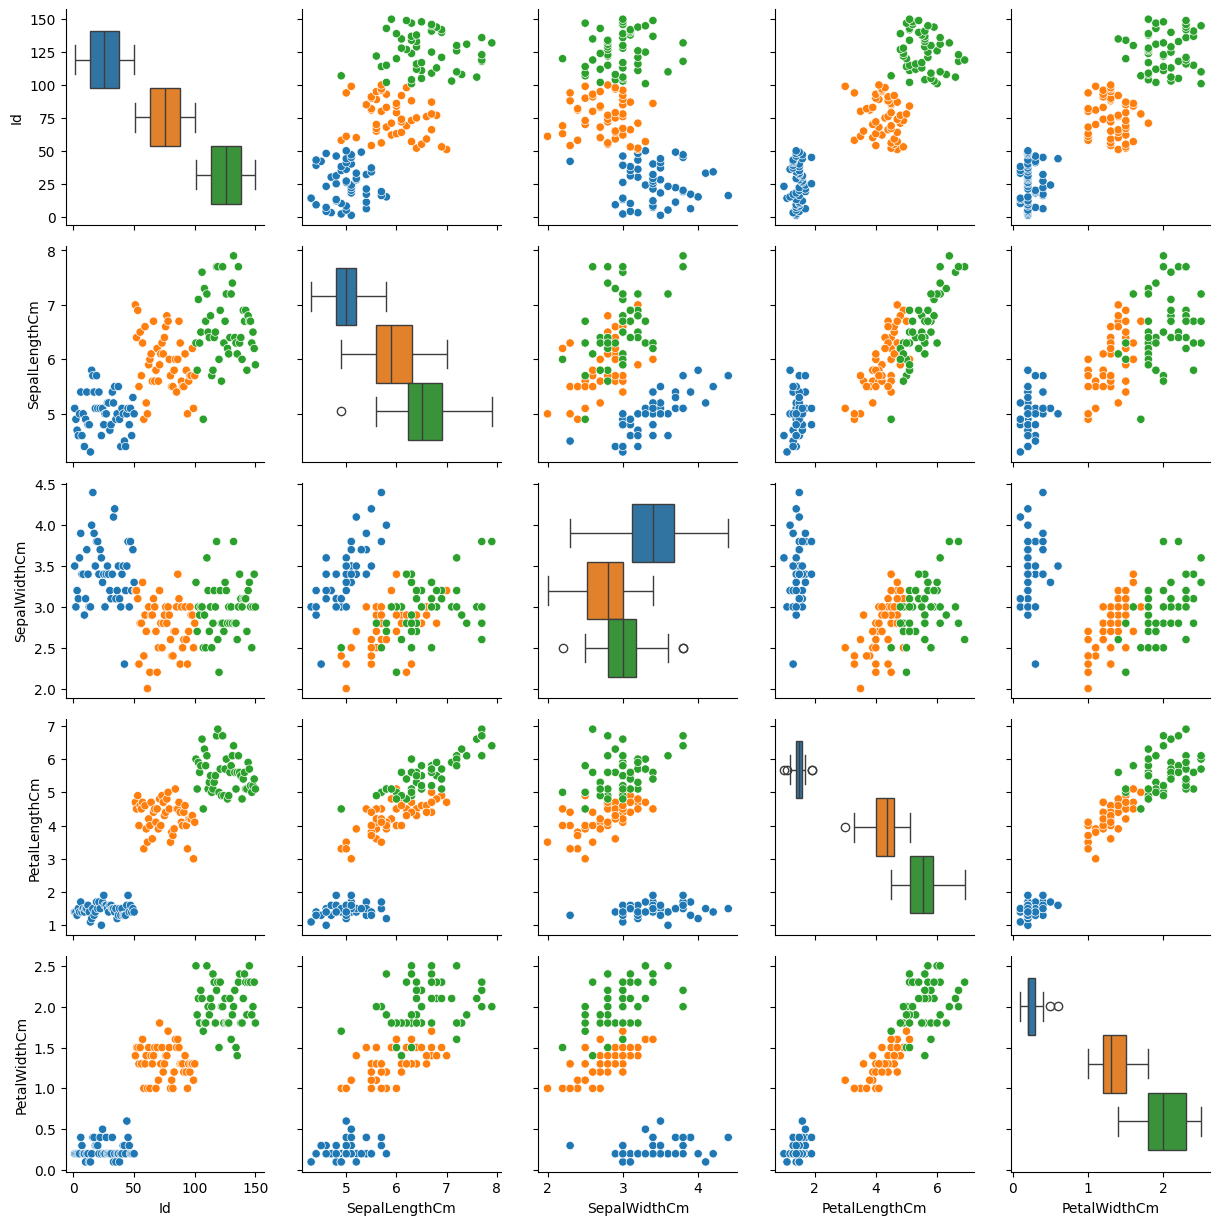

In [90]:
# we can plot diagonal items and off diagonal items differently using PairGrid
g = sns.PairGrid(iris,hue='Species')

# g -> grid object

# we can add all the all plots eg -> violinplot, 2dhistplot, kdeplot etc
g.map_diag(sns.boxplot)
g.map_offdiag(sns.scatterplot)

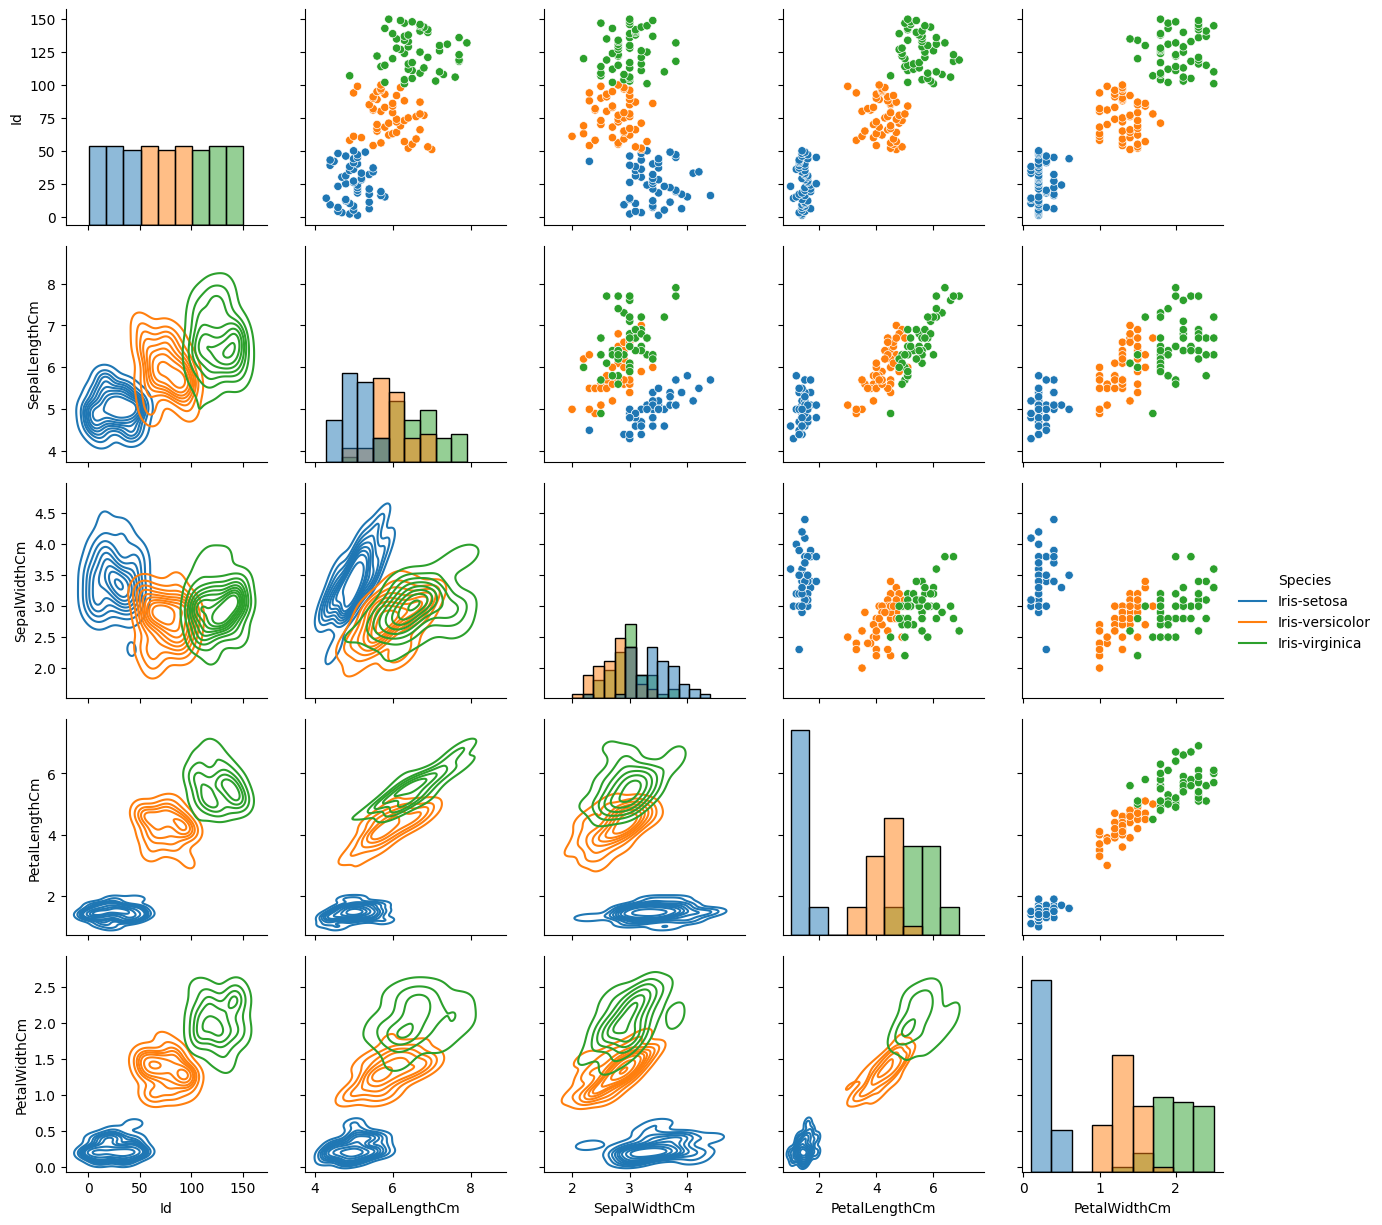

In [94]:
# plotting diff graphs on the upper and lower side
g = sns.PairGrid(iris,hue='Species')

# we can add all the all plots eg -> violinplot, 2dhistplot, kdeplot etc
g.map_diag(sns.histplot)        # diagonal
g.map_upper(sns.scatterplot)    # upper triangle
g.map_lower(sns.kdeplot)        # lower triangle

g.add_legend()

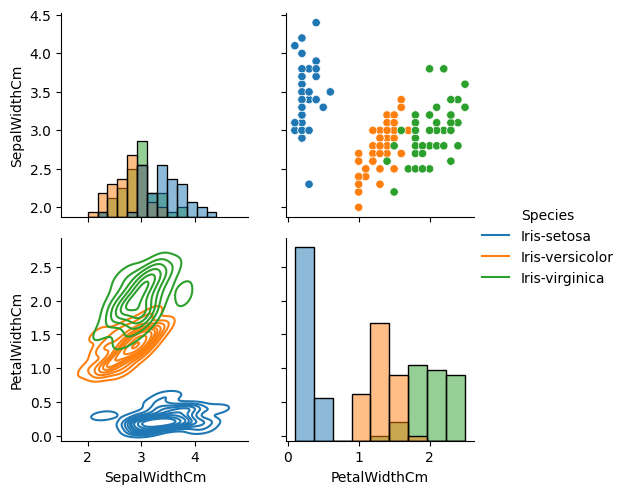

In [98]:
# vars parameter
# plotting diff graphs on the upper and lower side
g = sns.PairGrid(iris,hue='Species',vars=['SepalWidthCm','PetalWidthCm'])

# we can add all the all plots eg -> violinplot, 2dhistplot, kdeplot etc
g.map_diag(sns.histplot)        # diagonal
g.map_upper(sns.scatterplot)    # upper triangle
g.map_lower(sns.kdeplot)        # lower triangle

g.add_legend()

## JointGrid Vs Jointplot

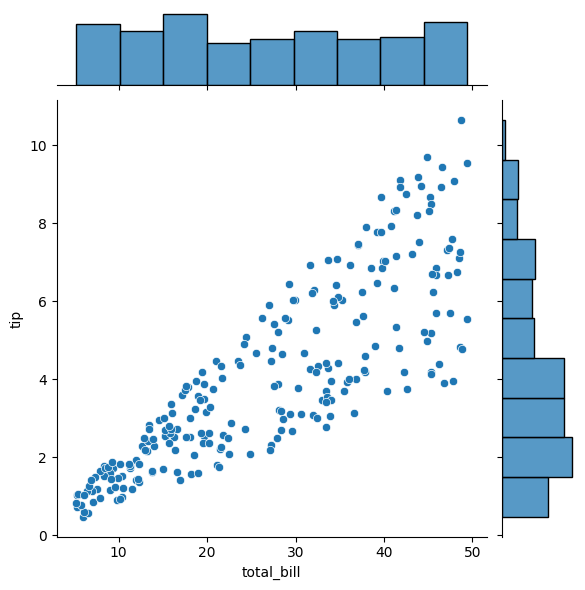

In [102]:
# jointplot
sns.jointplot(data=tips,x='total_bill',y='tip')

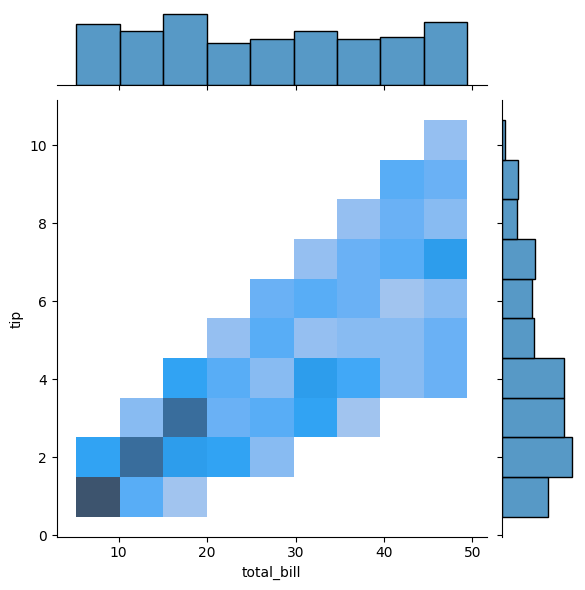

In [105]:
# kind parameter 
sns.jointplot(data=tips,x='total_bill',y='tip',kind='hist')

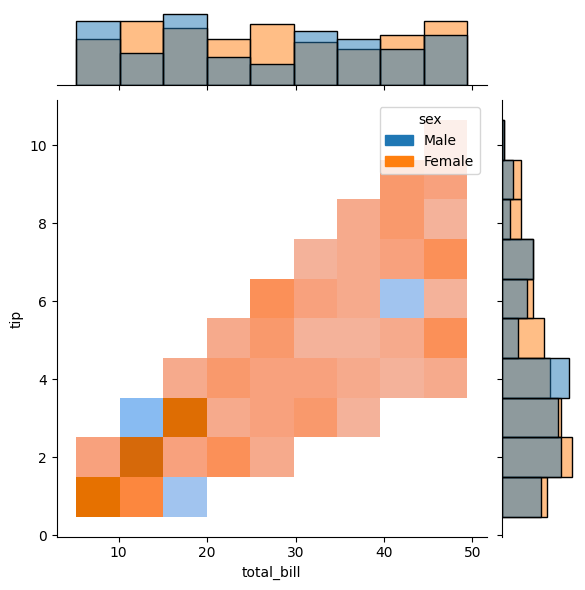

In [107]:
# hue parameter
sns.jointplot(data=tips,x='total_bill',y='tip',kind='hist',hue='sex')

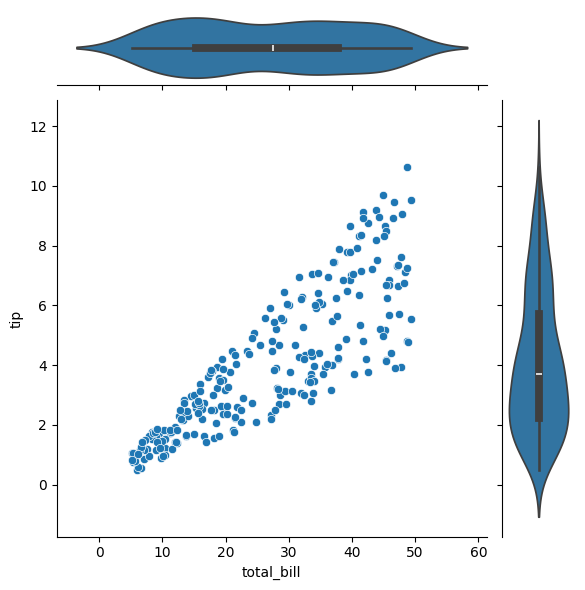

In [114]:
# jointgrid
g = sns.JointGrid(data=tips,x='total_bill',y='tip')

# g object
g.plot(sns.scatterplot,sns.violinplot)